In [4]:
# 데이터 확인하기 2025.11.19
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [ ]:
# 원본 데이터 불러오기
df = pd.read_csv("../data/train.csv")

pandas.core.series.Series

In [ ]:
remove_cols = pd.read_csv('../doc/remove_cols.csv', header=0).squeeze()
df.drop(columns=remove_cols, axis=1, inplace=True)
df.drop(columns=['ID', 'TARGET'], axis=1, inplace=True) # ID와 TARGET 모두 제거

In [25]:
print(df.shape) # (76020, 154)
desc = df.describe()
desc.to_csv('../data/df_describe_after_removed_cols.csv')
desc.loc['min']

(76020, 152)


var3                            -999999.00
var15                                 5.00
imp_ent_var16_ult1                    0.00
imp_op_var39_comer_ult1               0.00
imp_op_var39_comer_ult3               0.00
                                   ...    
saldo_medio_var13_corto_hace2         0.00
saldo_medio_var13_corto_hace3         0.00
saldo_medio_var13_corto_ult1          0.00
saldo_medio_var13_corto_ult3          0.00
var38                              5163.75
Name: min, Length: 152, dtype: float64

In [18]:
# 3. IQR 기반 이상치 기준 계산
Q1 = desc.loc["25%"]
Q3 = desc.loc["75%"]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [26]:
# 이상치 마스킹 (컬럼별로)
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.select_dtypes(include="number").columns:
    if col in lower_bound.index:
        lb = lower_bound[col]
        ub = upper_bound[col]
        outlier_mask[col] = (df[col] < lb) | (df[col] > ub)

# 5. 이상치 기준 + 마스크를 outlier_bounds에 통합
outlier_bounds = pd.DataFrame({
    "min" : desc.loc['min'],
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "max": desc.loc['max'],
    "LowerBound": lower_bound,
    "UpperBound": upper_bound,
    "OutlierCount": outlier_mask.sum()
})

print(outlier_bounds)


                                     min          Q1           Q3       IQR  \
var3                          -999999.00      2.0000       2.0000      0.00   
var15                               5.00     23.0000      40.0000     17.00   
imp_ent_var16_ult1                  0.00      0.0000       0.0000      0.00   
imp_op_var39_comer_ult1             0.00      0.0000       0.0000      0.00   
imp_op_var39_comer_ult3             0.00      0.0000       0.0000      0.00   
...                                  ...         ...          ...       ...   
saldo_medio_var13_corto_hace2       0.00      0.0000       0.0000      0.00   
saldo_medio_var13_corto_hace3       0.00      0.0000       0.0000      0.00   
saldo_medio_var13_corto_ult1        0.00      0.0000       0.0000      0.00   
saldo_medio_var13_corto_ult3        0.00      0.0000       0.0000      0.00   
var38                            5163.75  67870.6125  118756.2525  50885.64   

                                       max  LowerBo

In [27]:
outlier_bounds.to_csv('../data/outlier_bounds_154cols.csv')

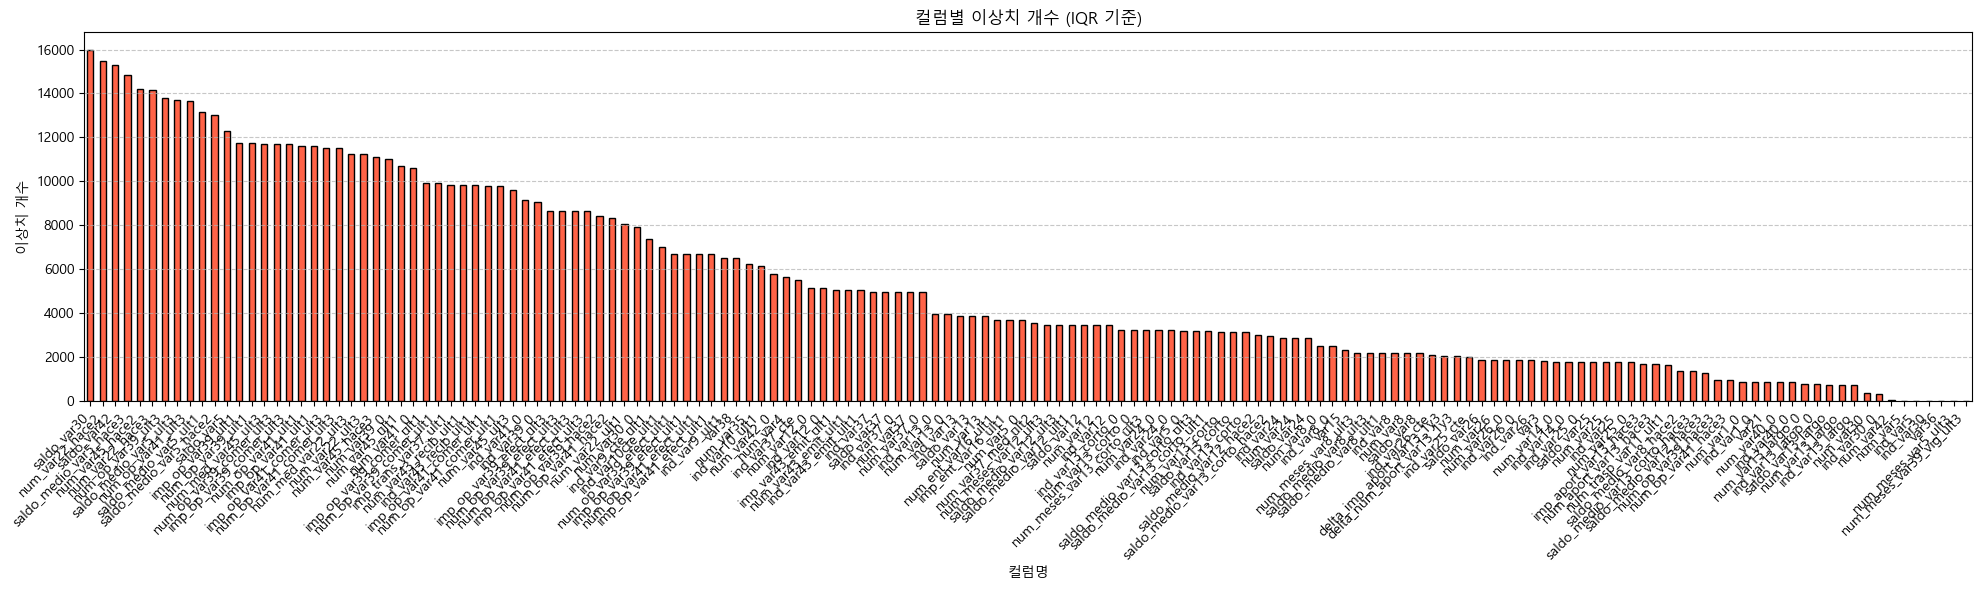

In [28]:
# 시각화
outlier_series = outlier_bounds['OutlierCount'].sort_values(ascending=False)

plt.figure(figsize=(20, 6))
outlier_series.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("컬럼별 이상치 개수 (IQR 기준)")
plt.ylabel("이상치 개수")
plt.xlabel("컬럼명")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print(outlier_series[outlier_series > 0], outlier_series[outlier_series > 10], outlier_series[outlier_series > 50], outlier_series[outlier_series > 100])
# 0 보다 큰  147
# 10 보다 큰 146개
# 50 보다 큰 145개
# 100 보다 큰 145

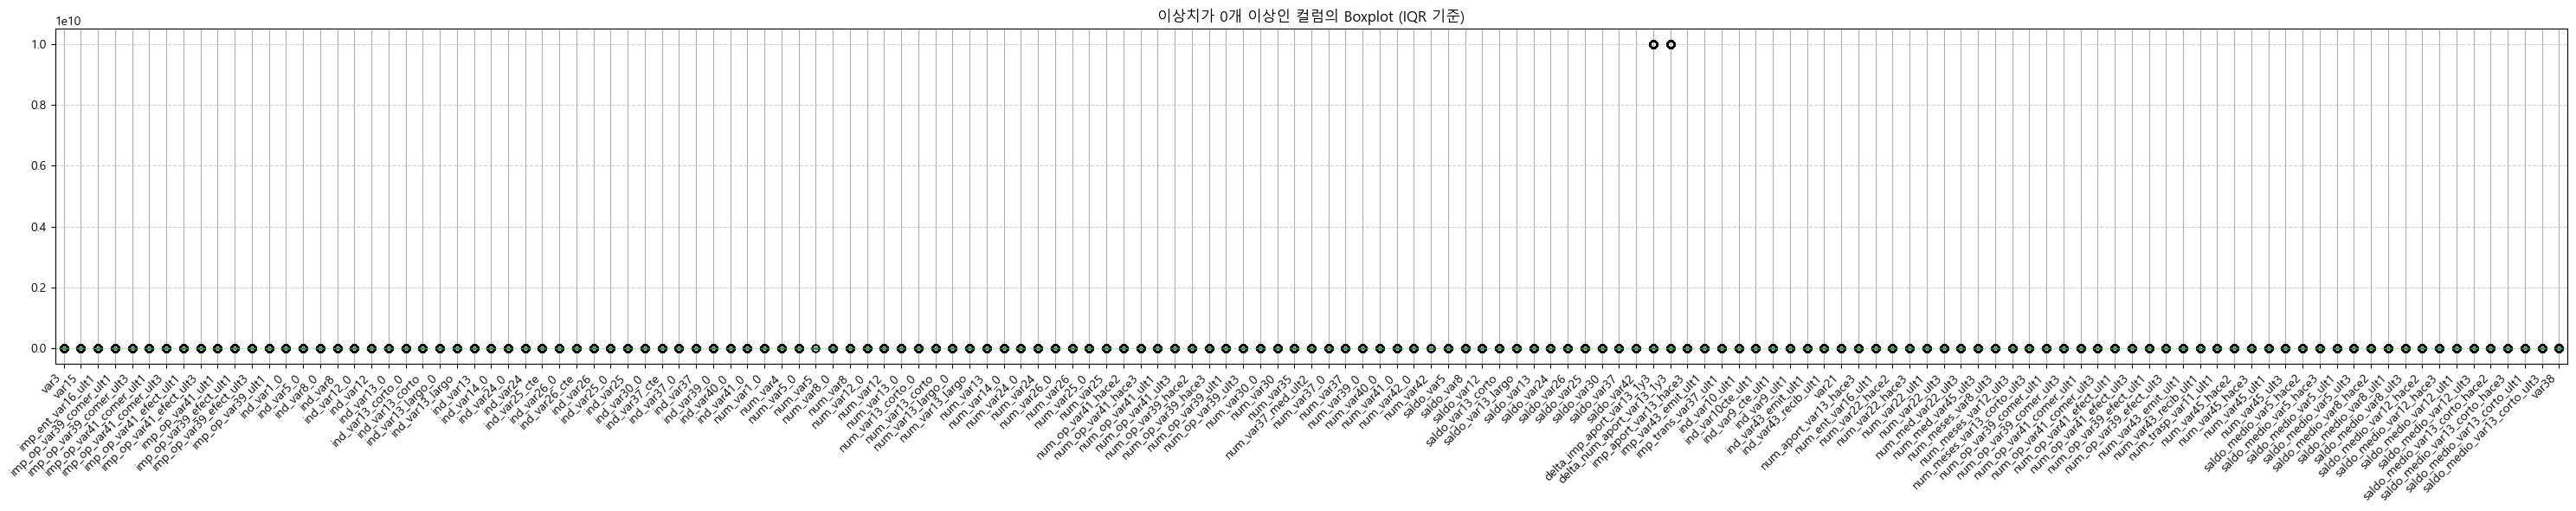

In [31]:
# 5. 이상치가 n개 이상인 컬럼만 필터링
ncnt = 0
selected_cols = outlier_bounds[outlier_bounds["OutlierCount"] > ncnt].index.tolist()

# 6. Boxplot 시각화
plt.figure(figsize=(30, 6))
df[selected_cols].boxplot()
plt.title(f"이상치가 {ncnt}개 이상인 컬럼의 Boxplot (IQR 기준)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


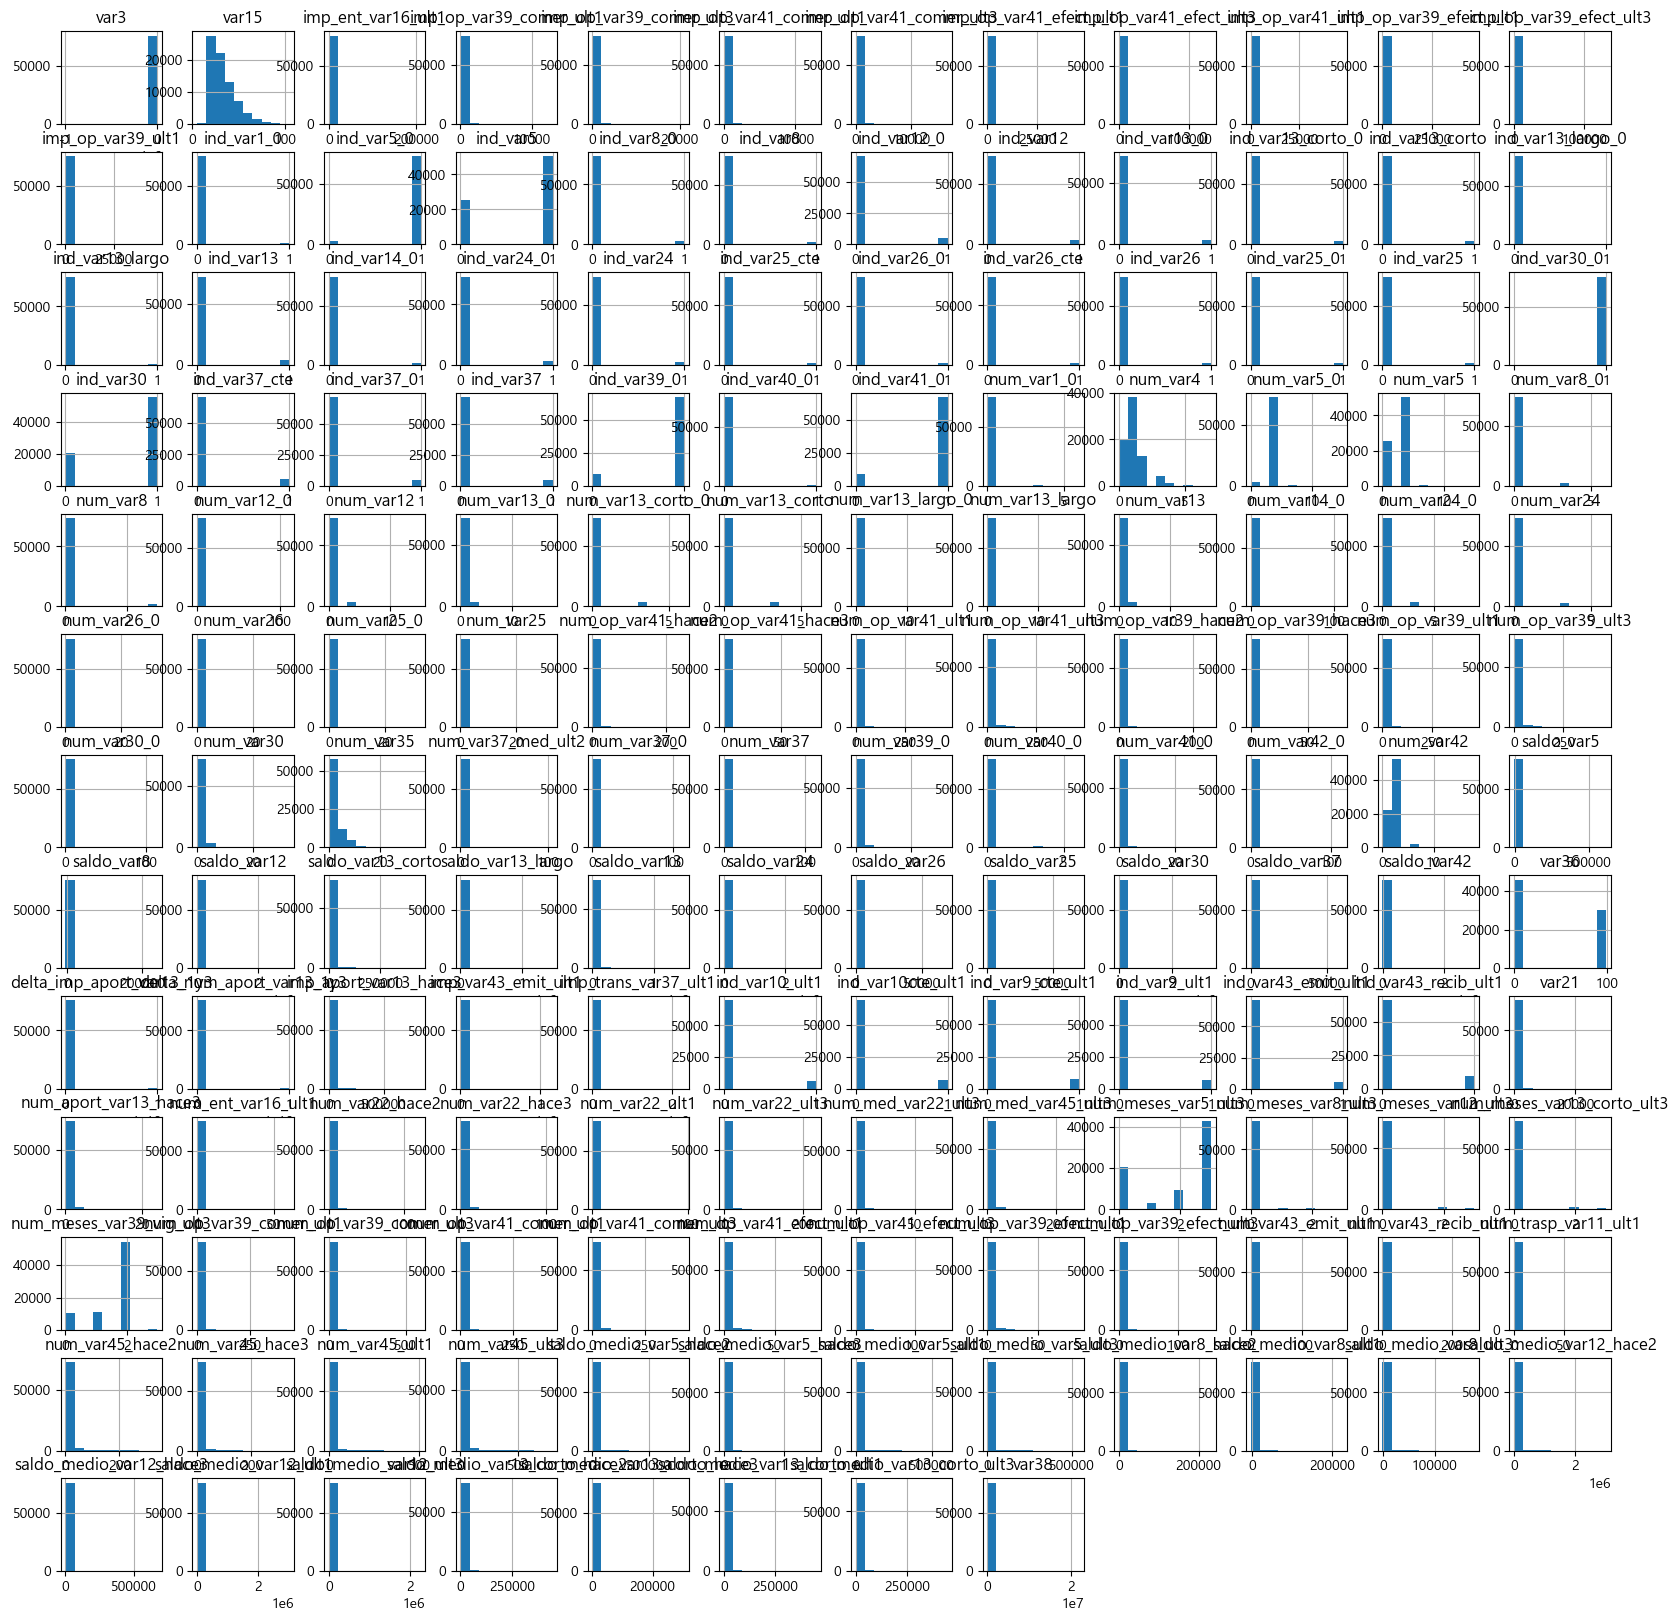

In [32]:
df.hist(figsize=(20, 20))
plt.show()

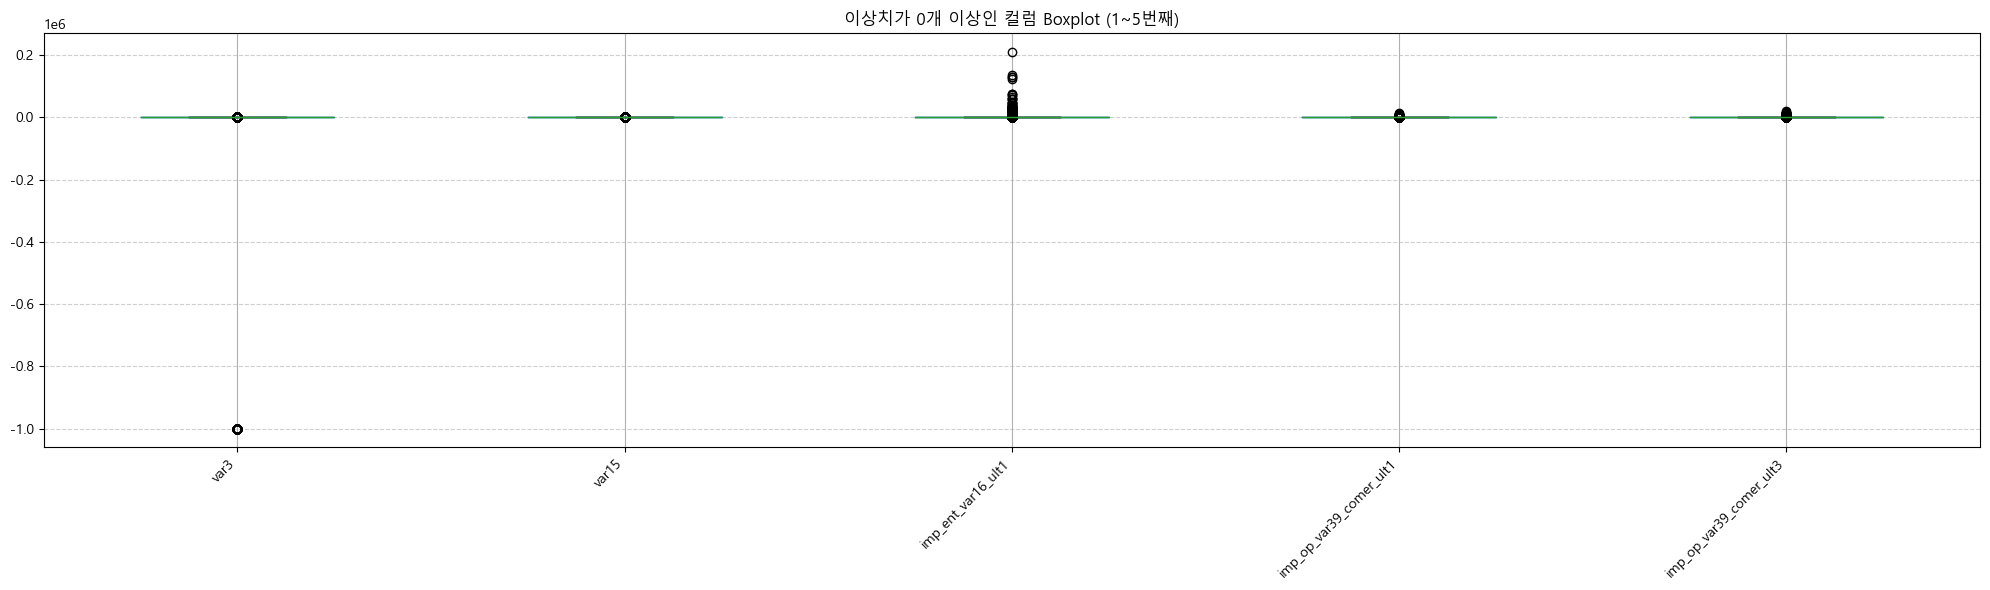

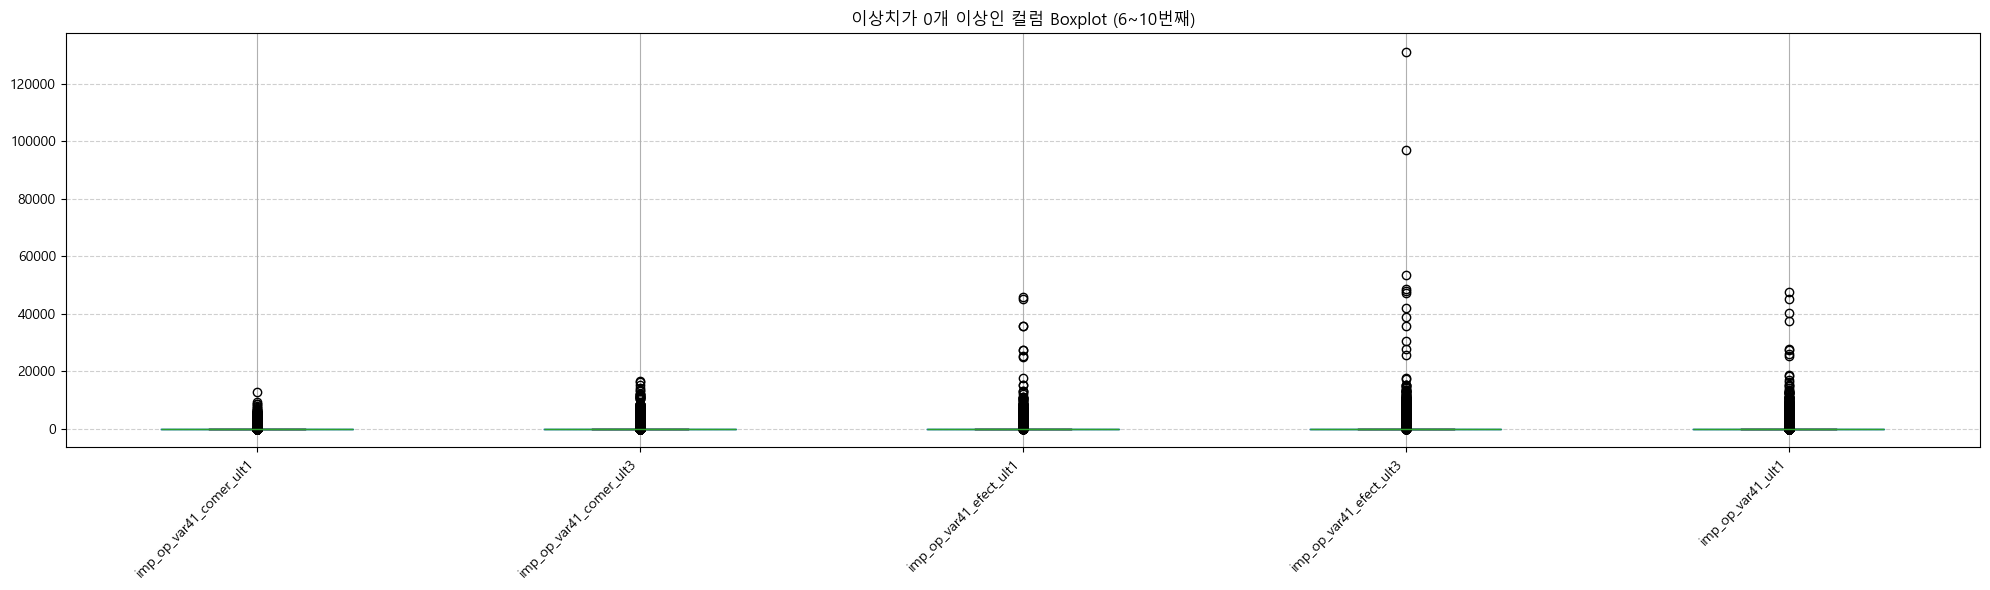

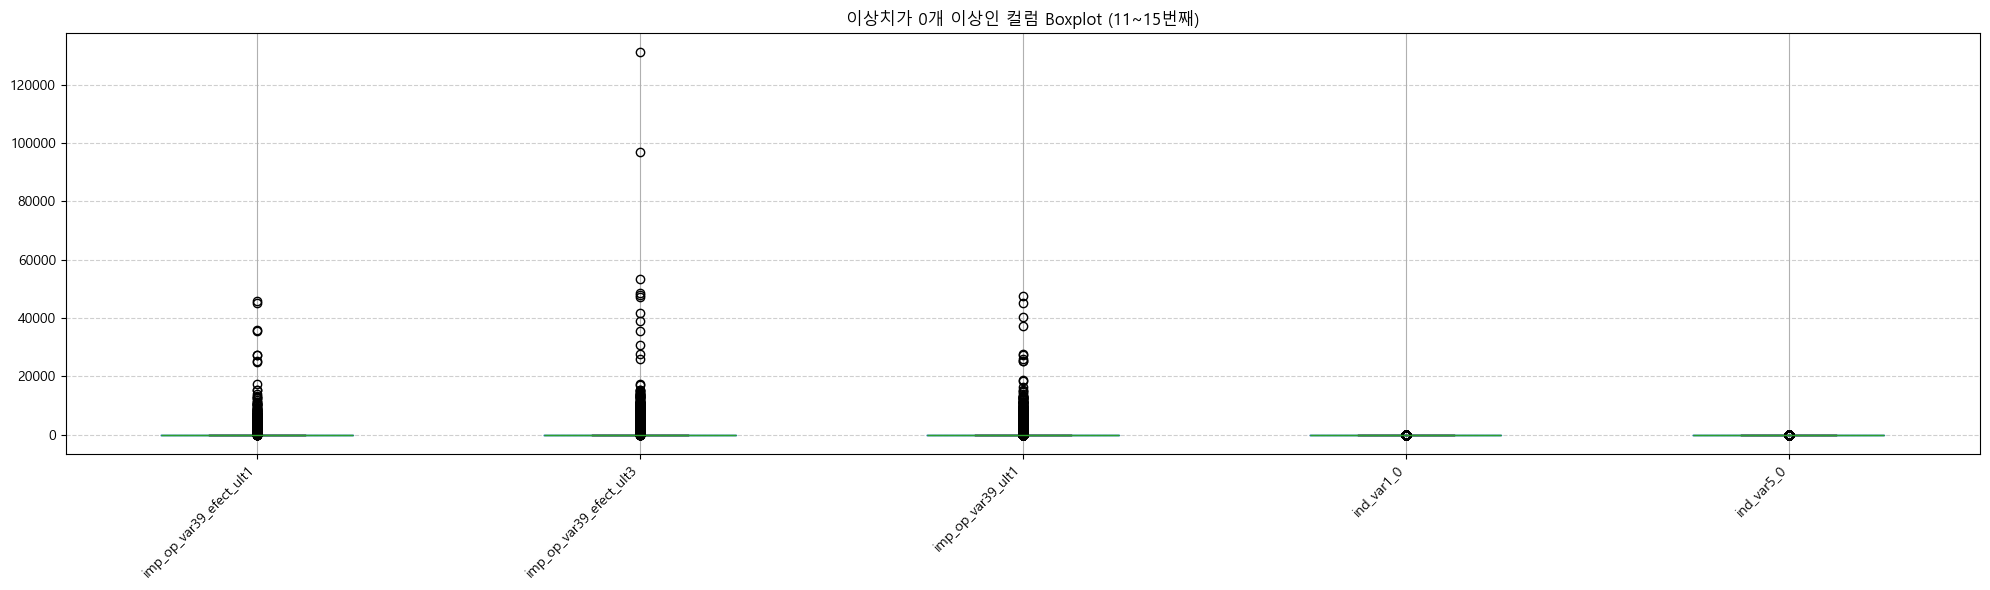

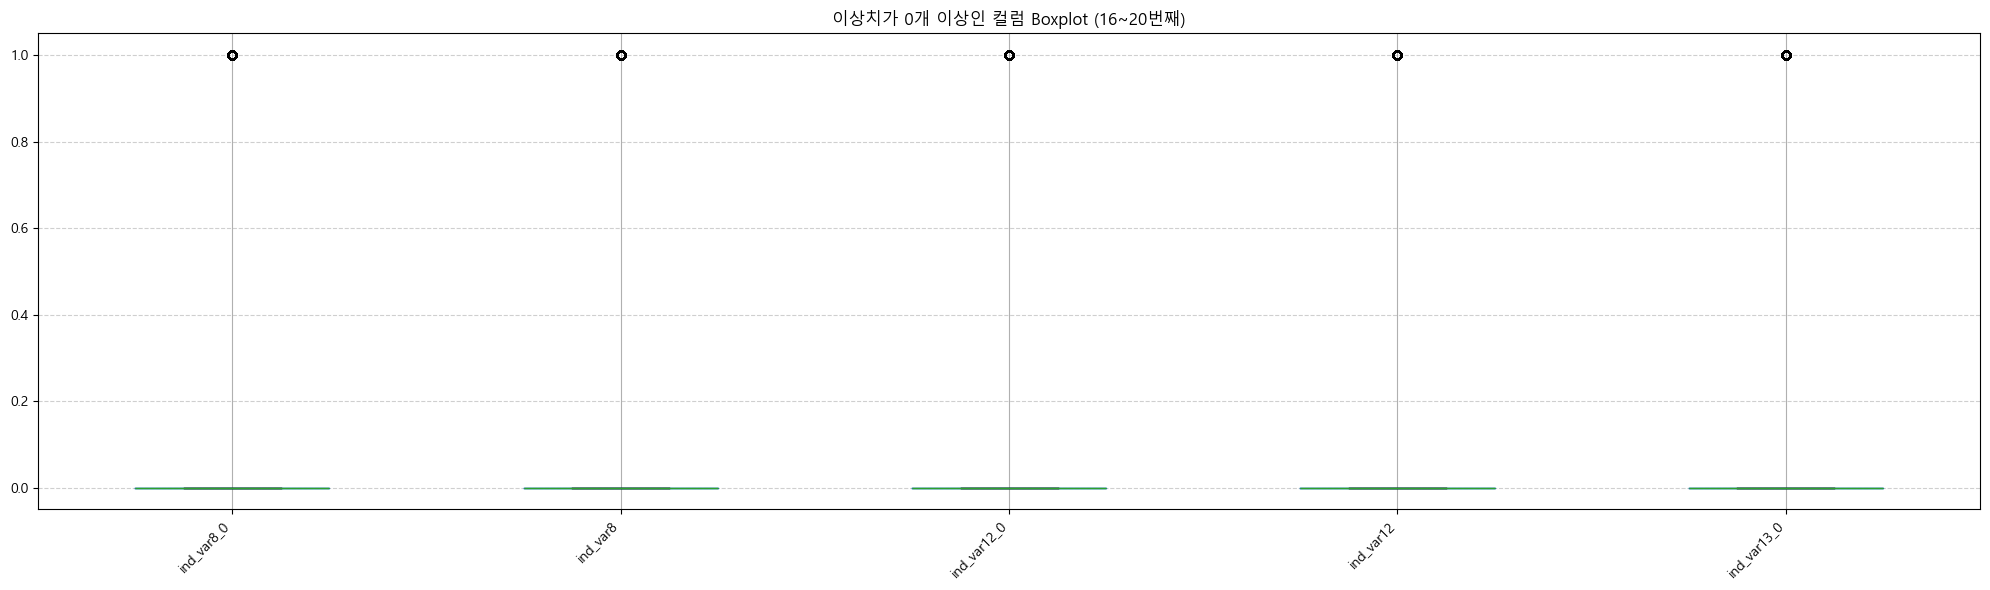

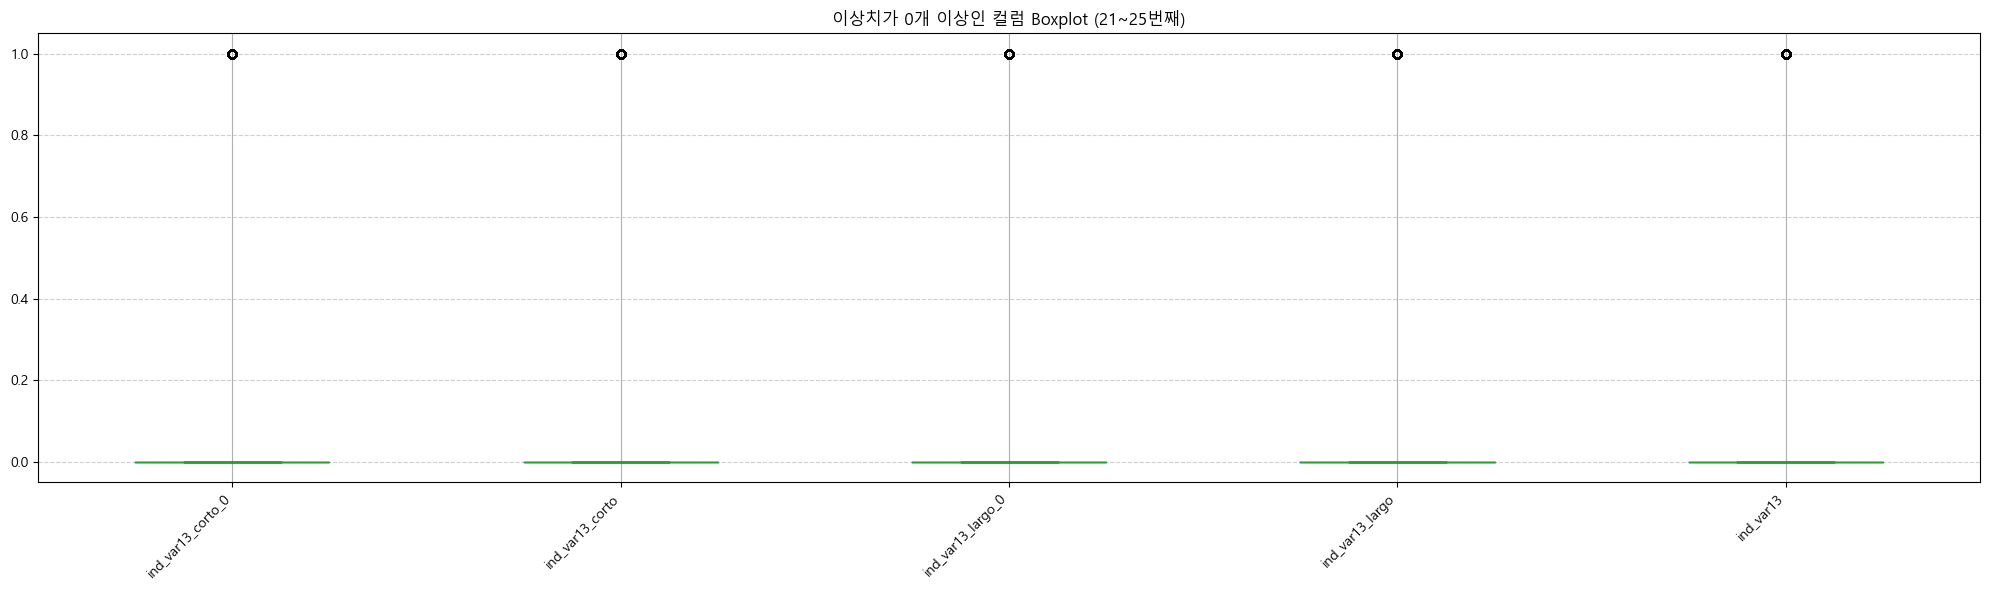

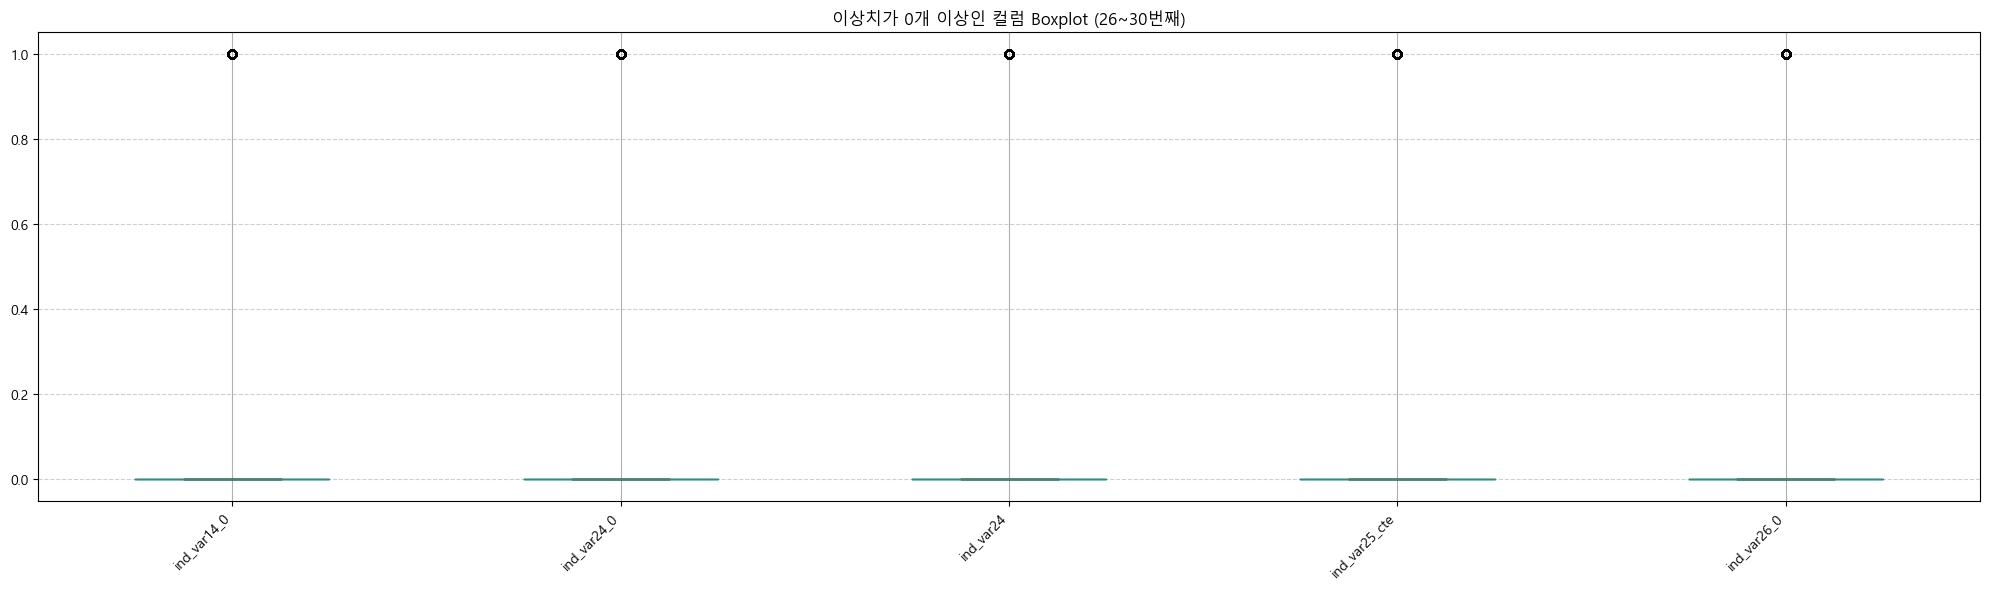

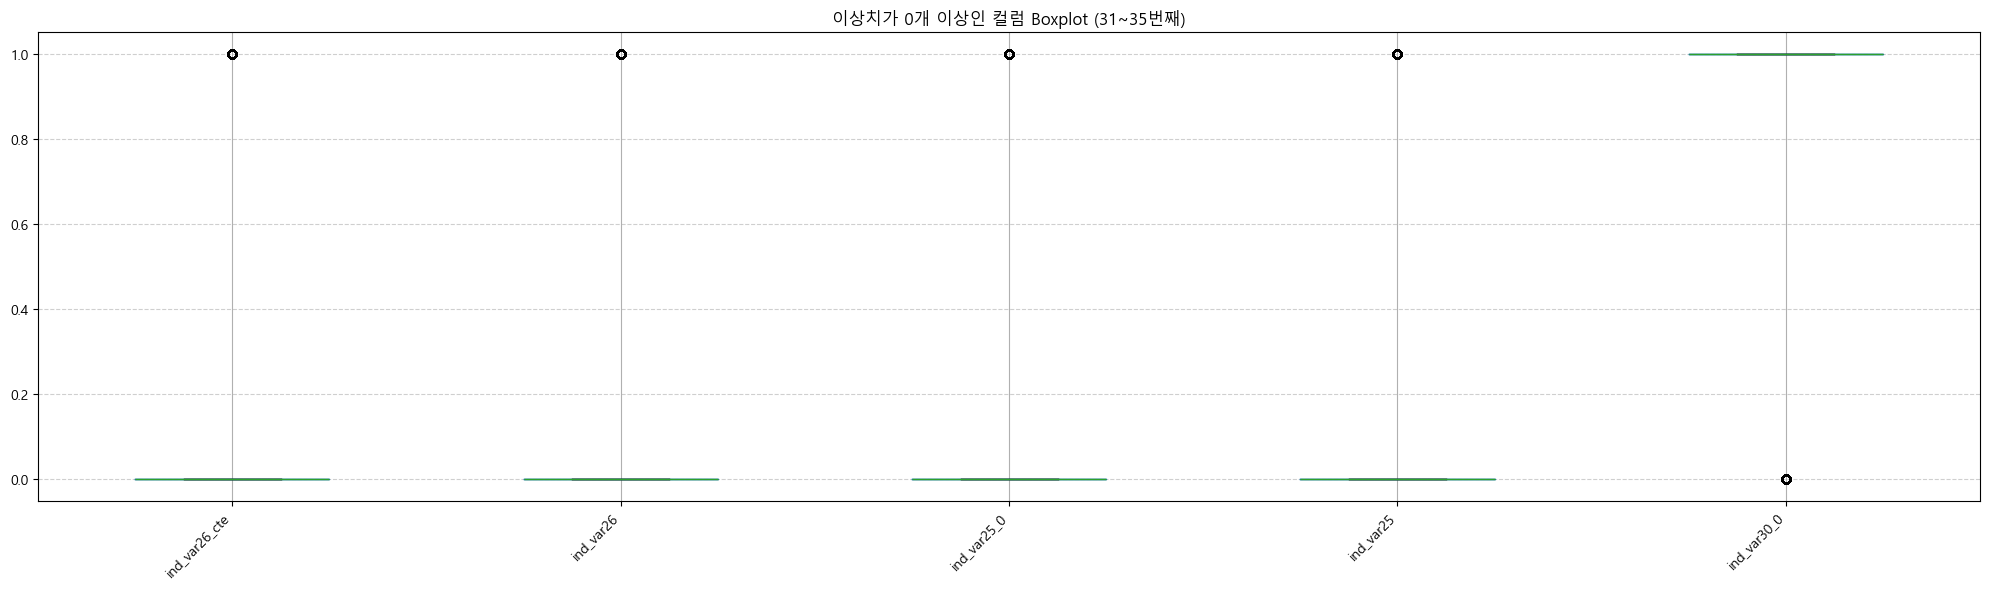

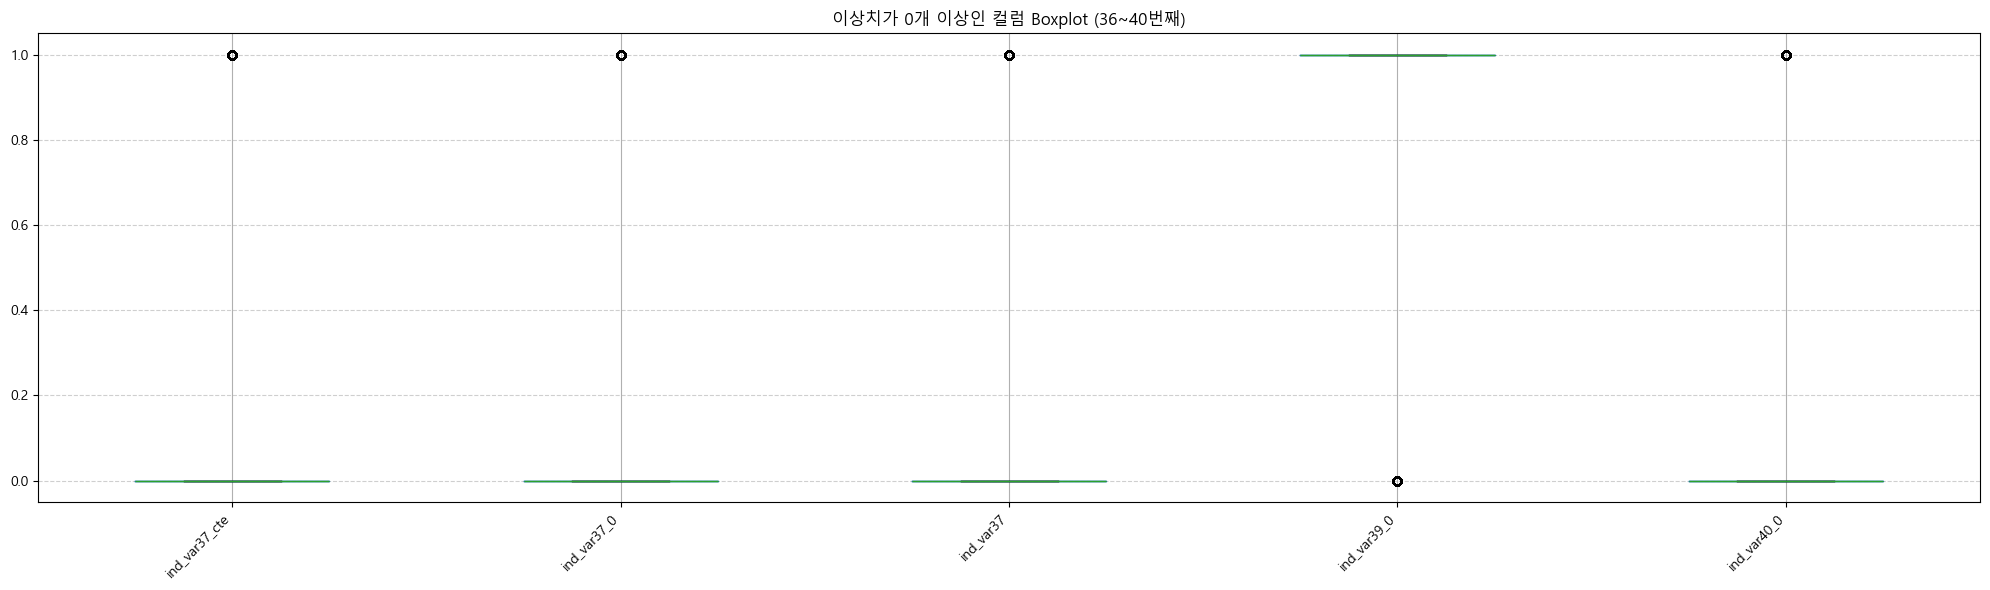

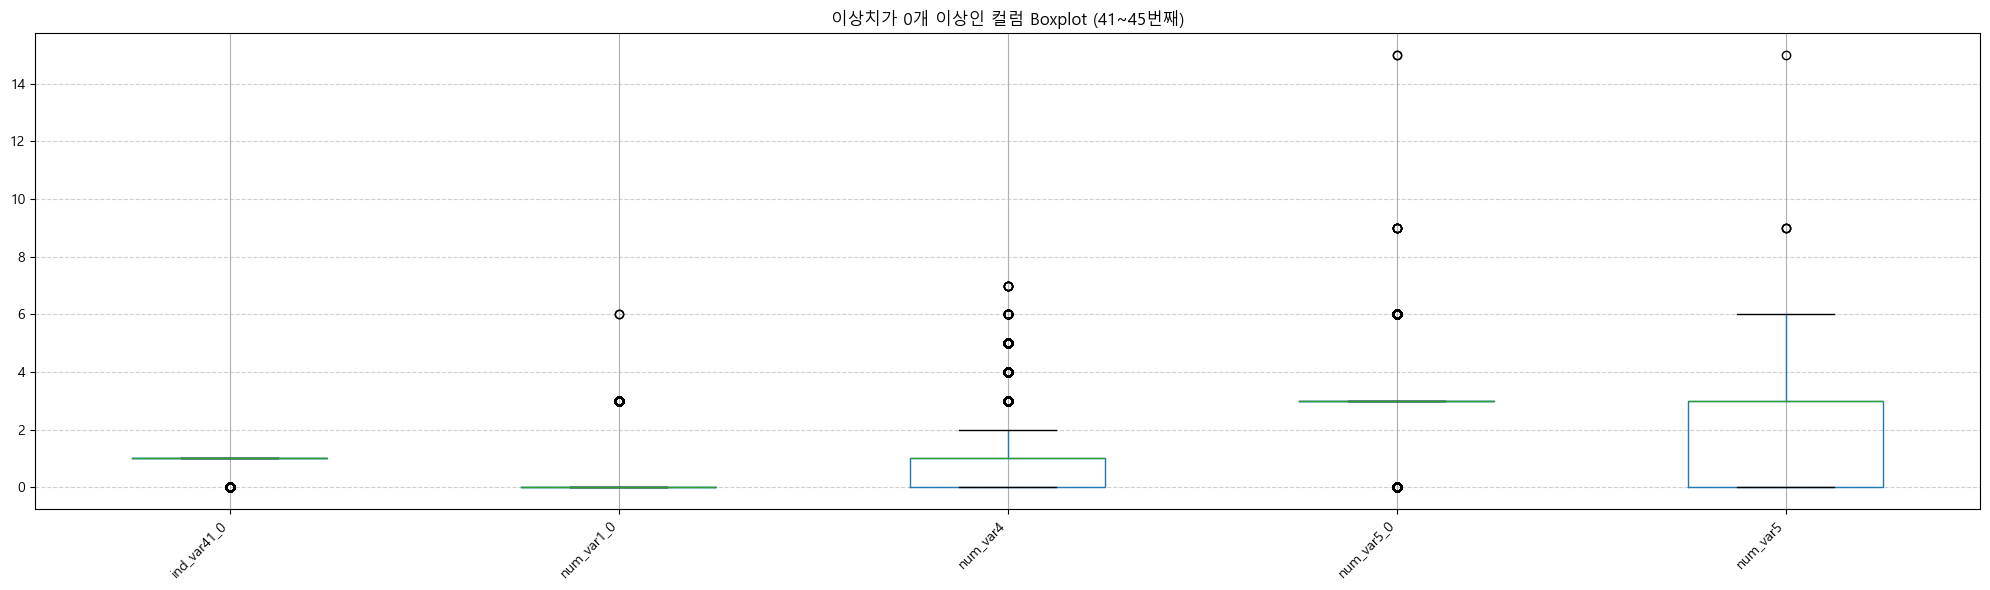

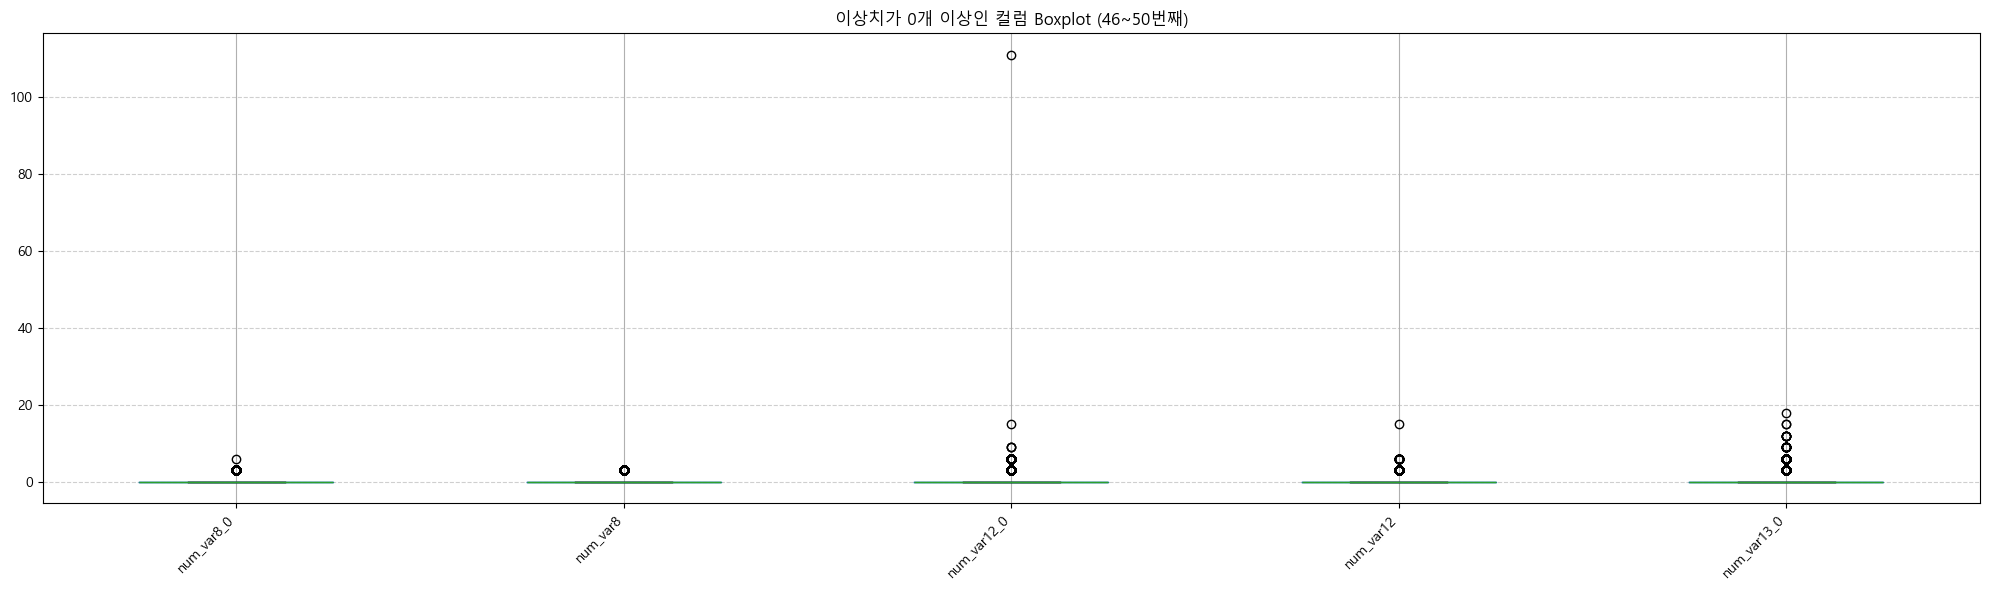

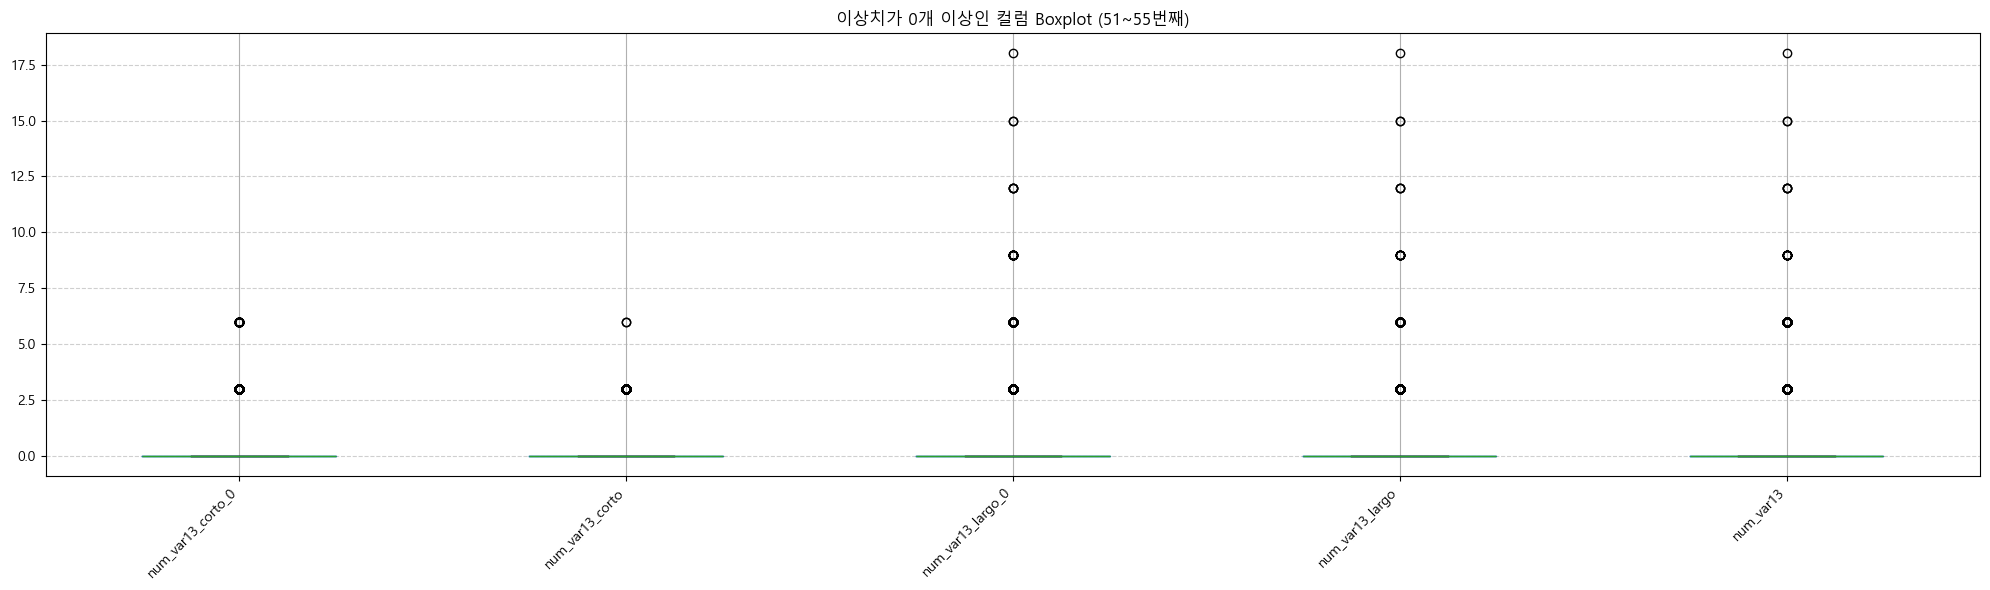

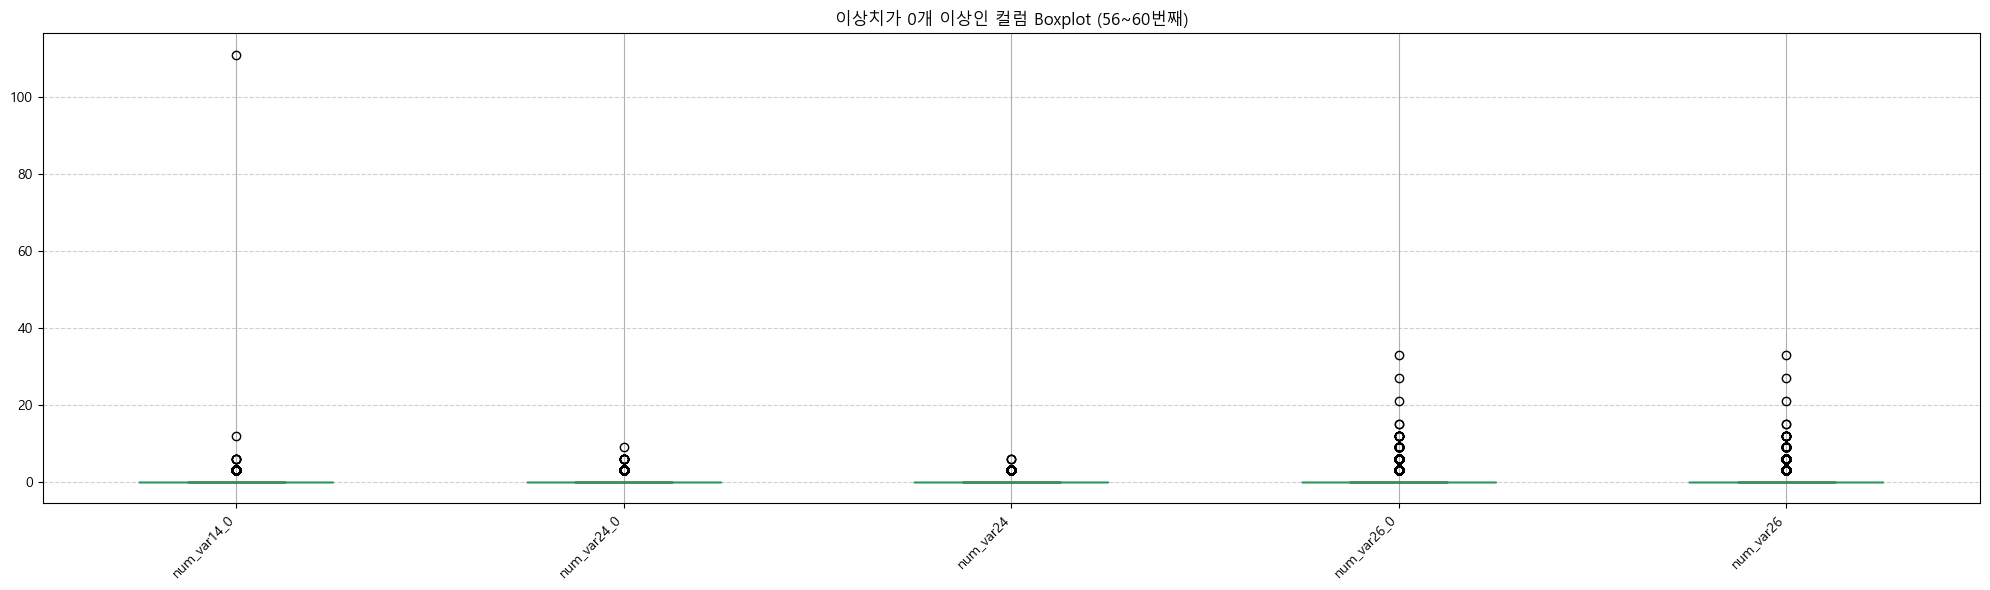

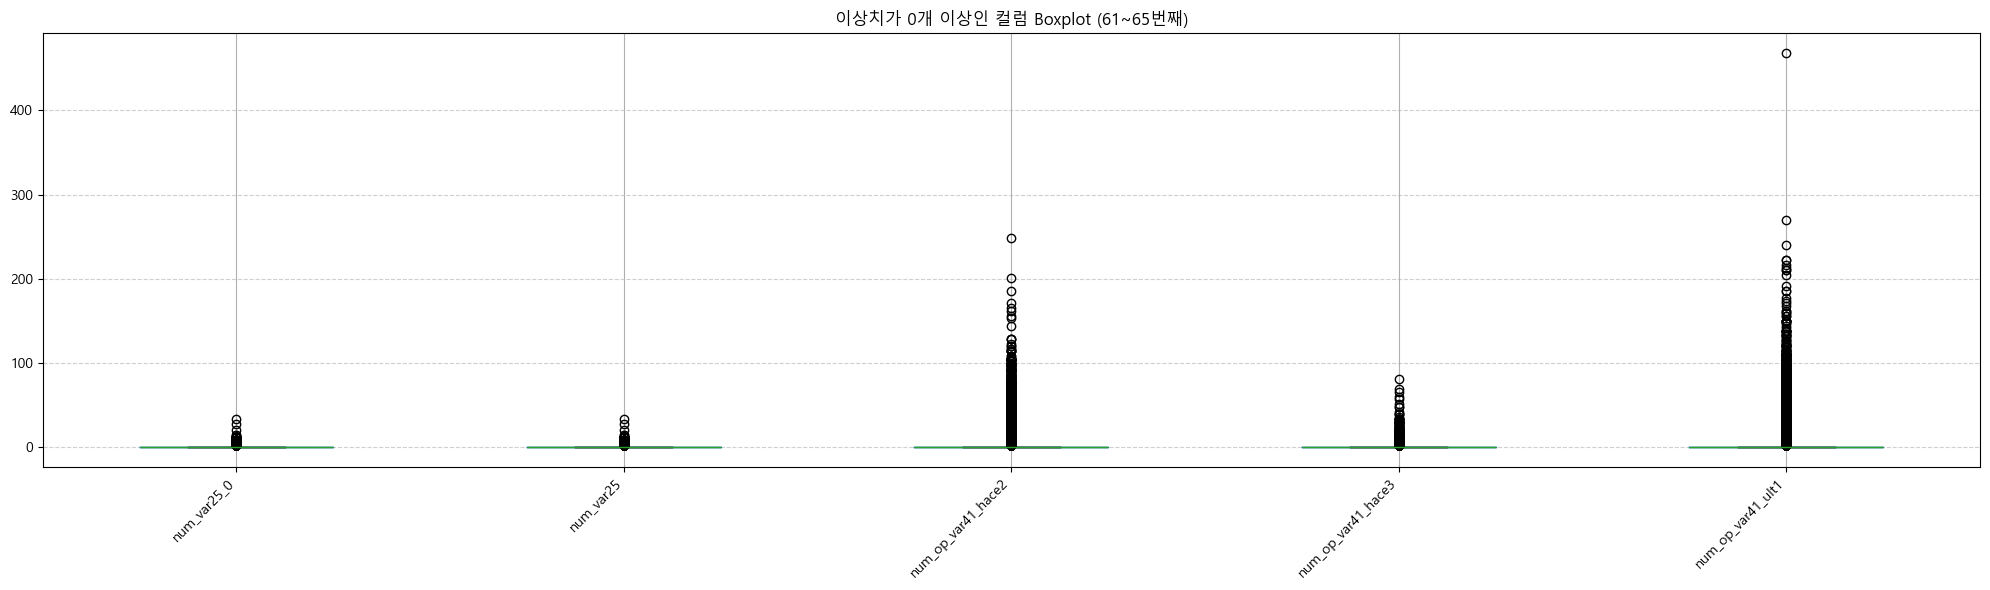

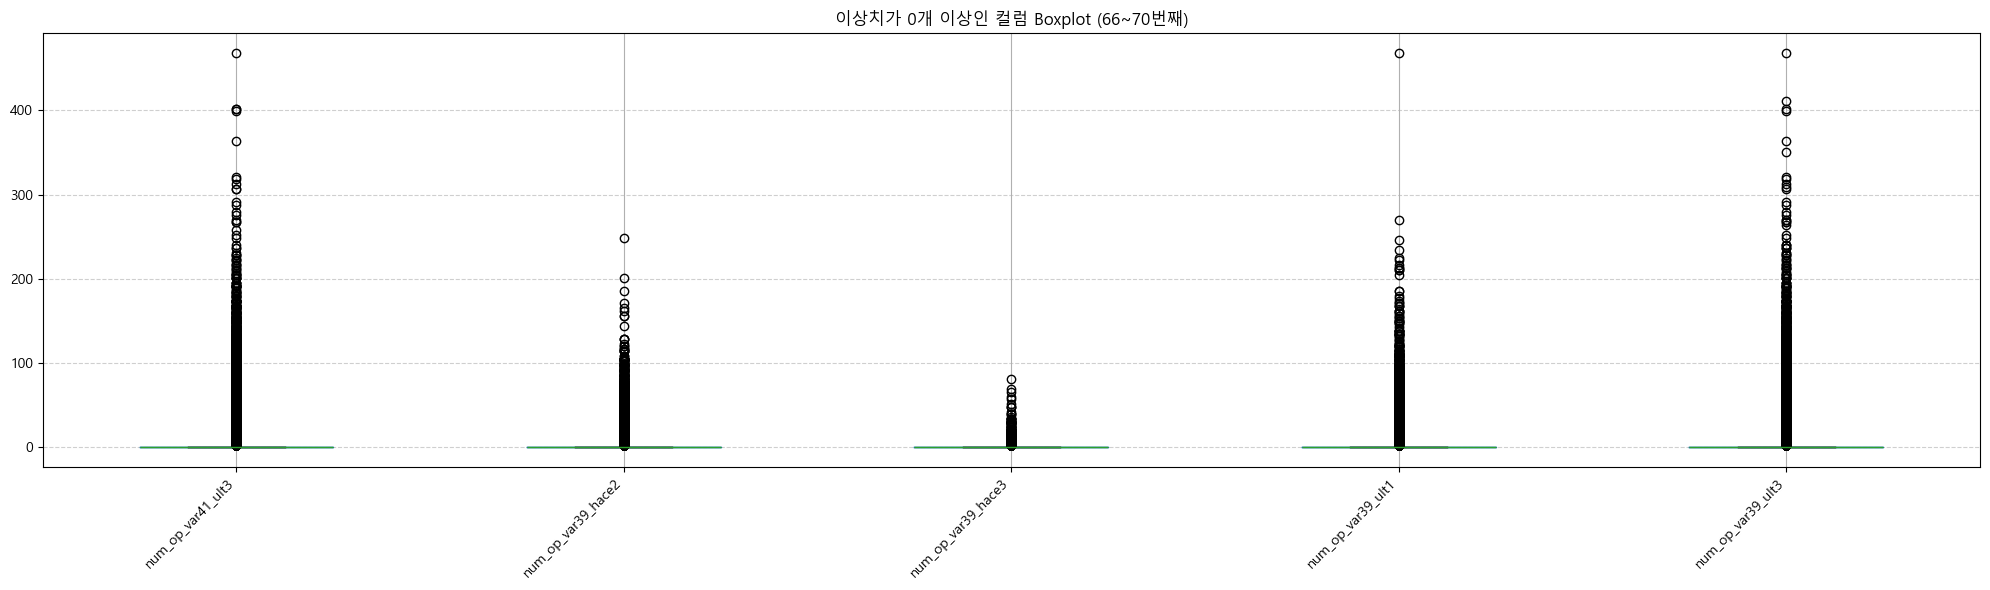

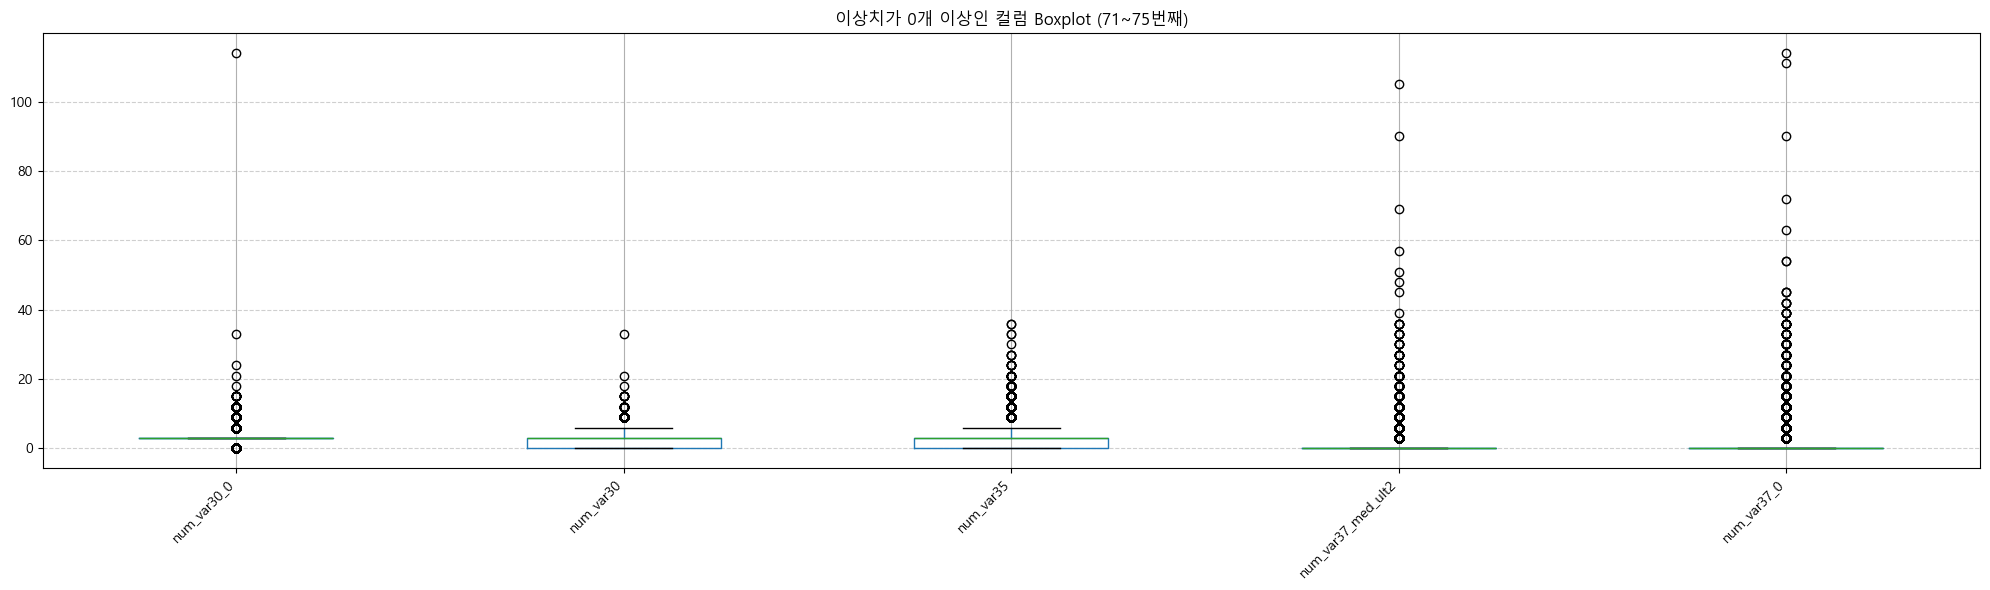

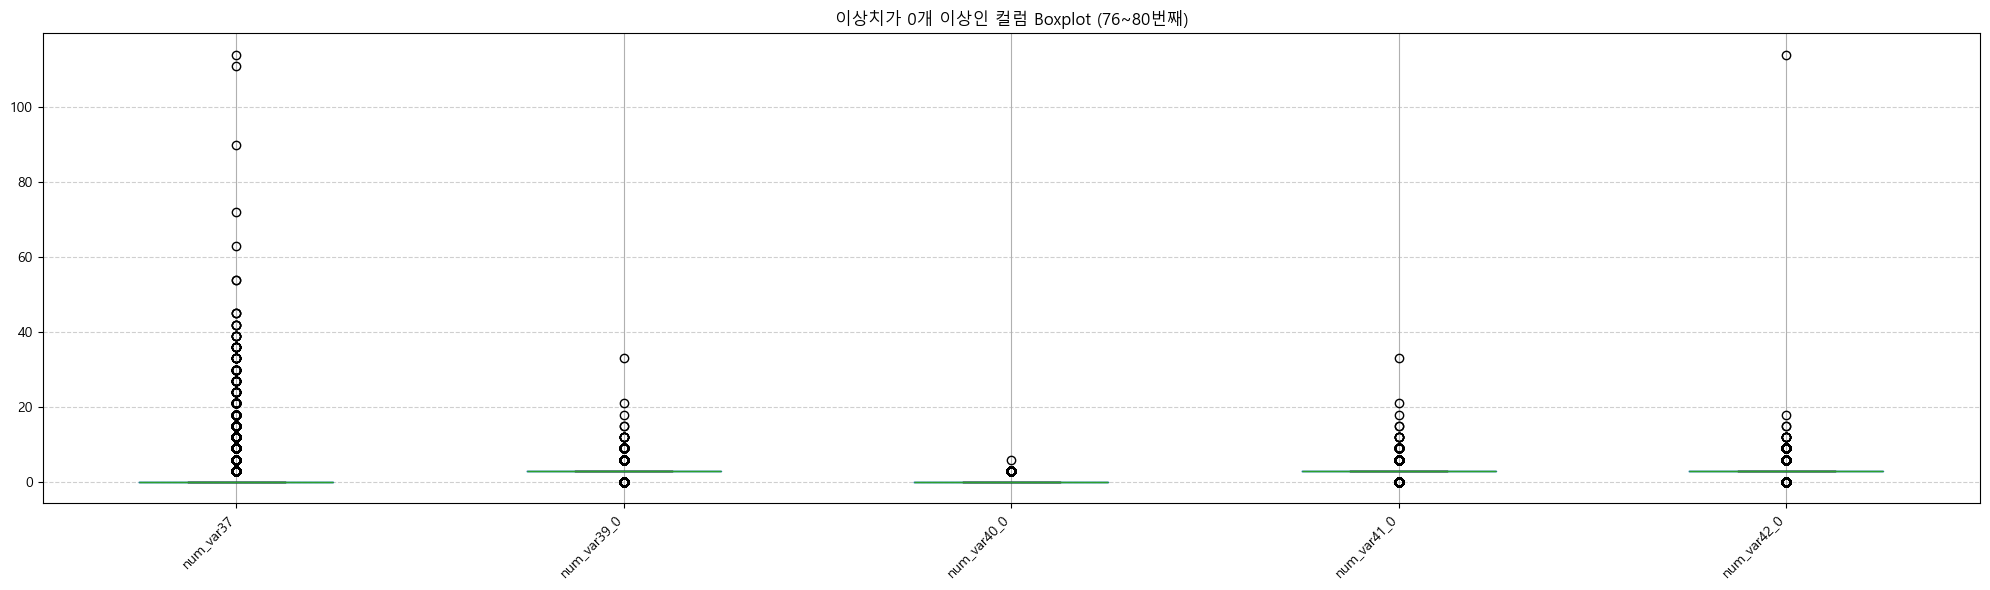

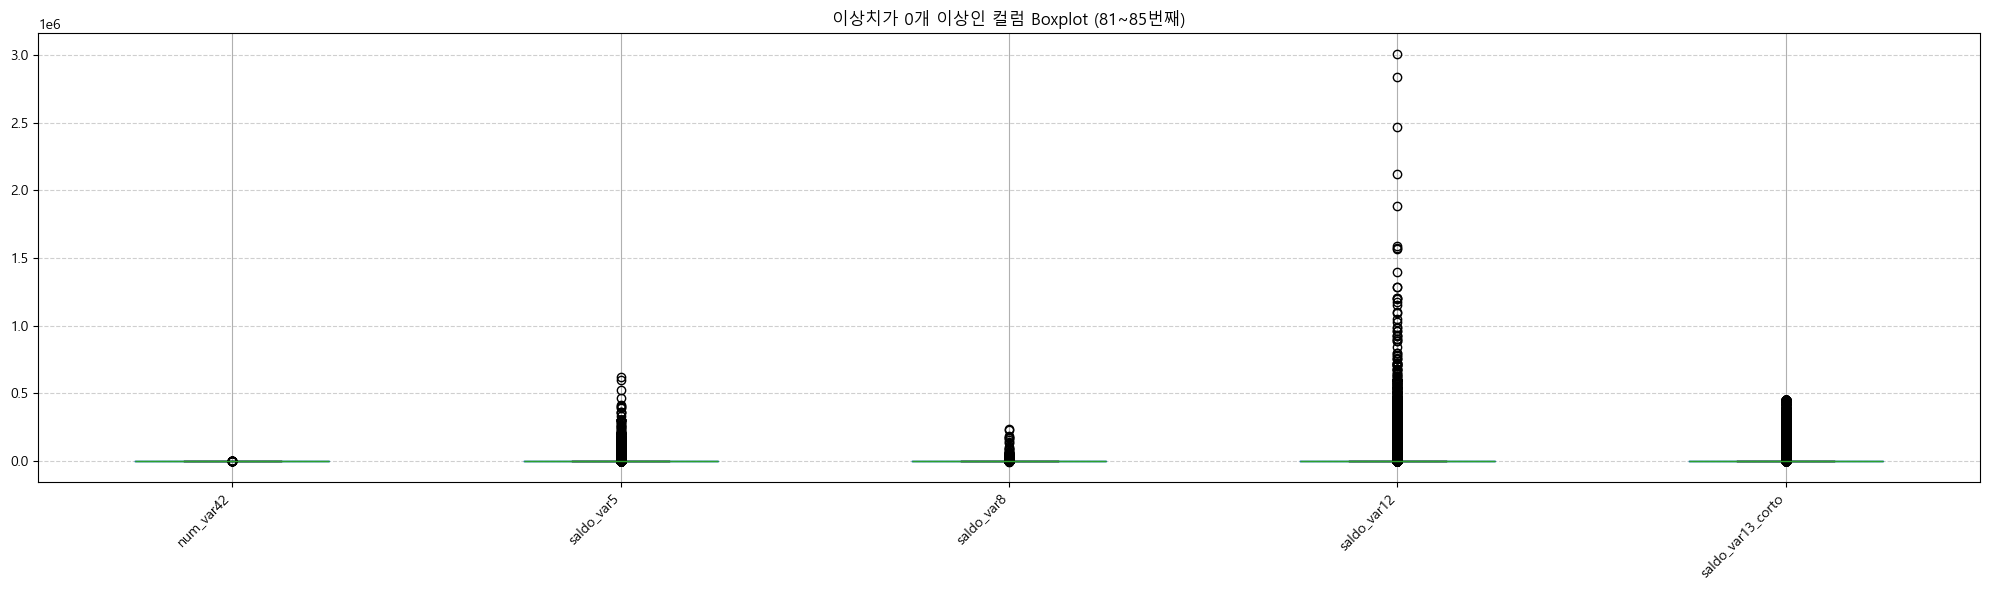

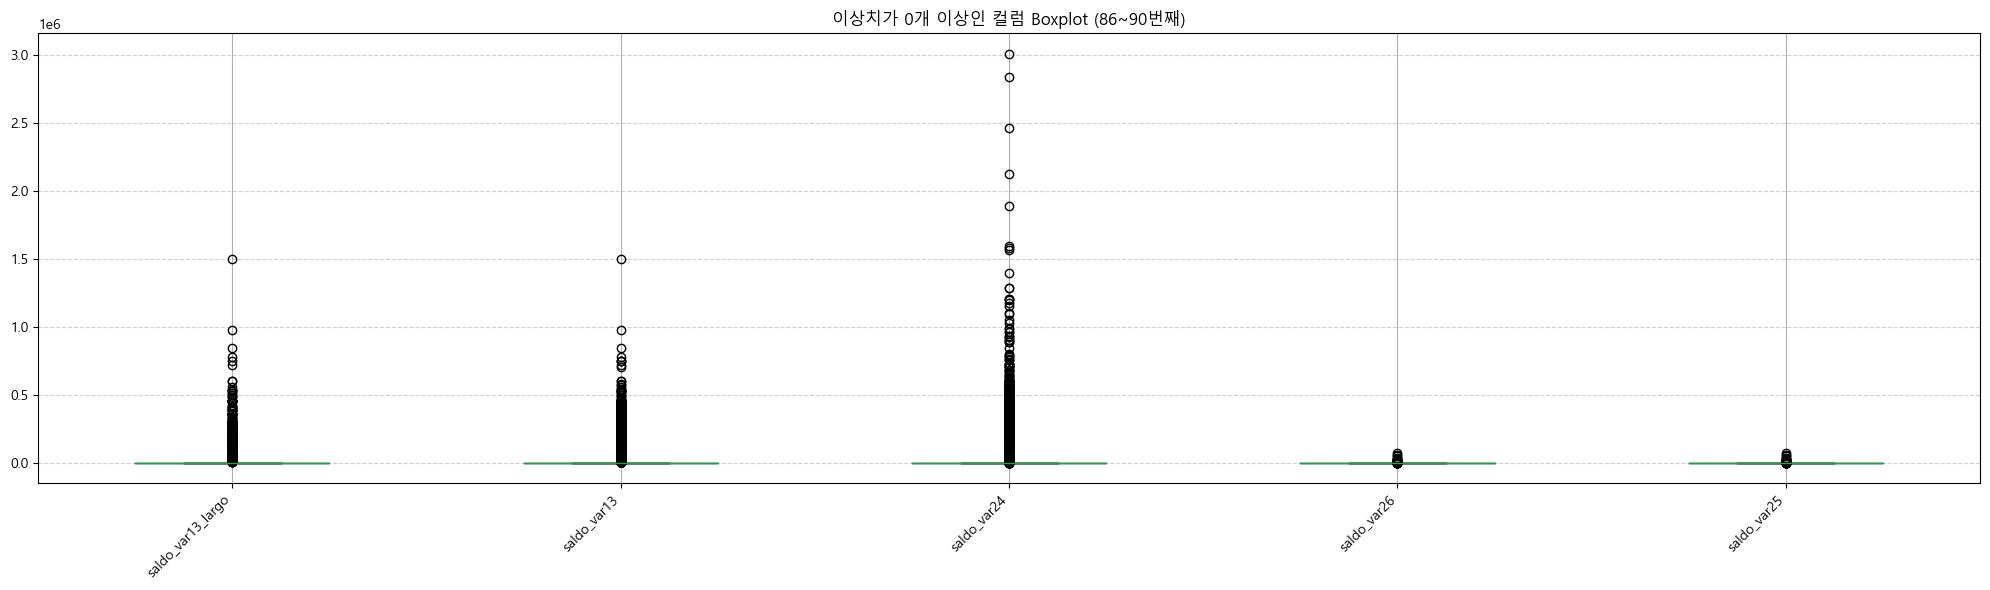

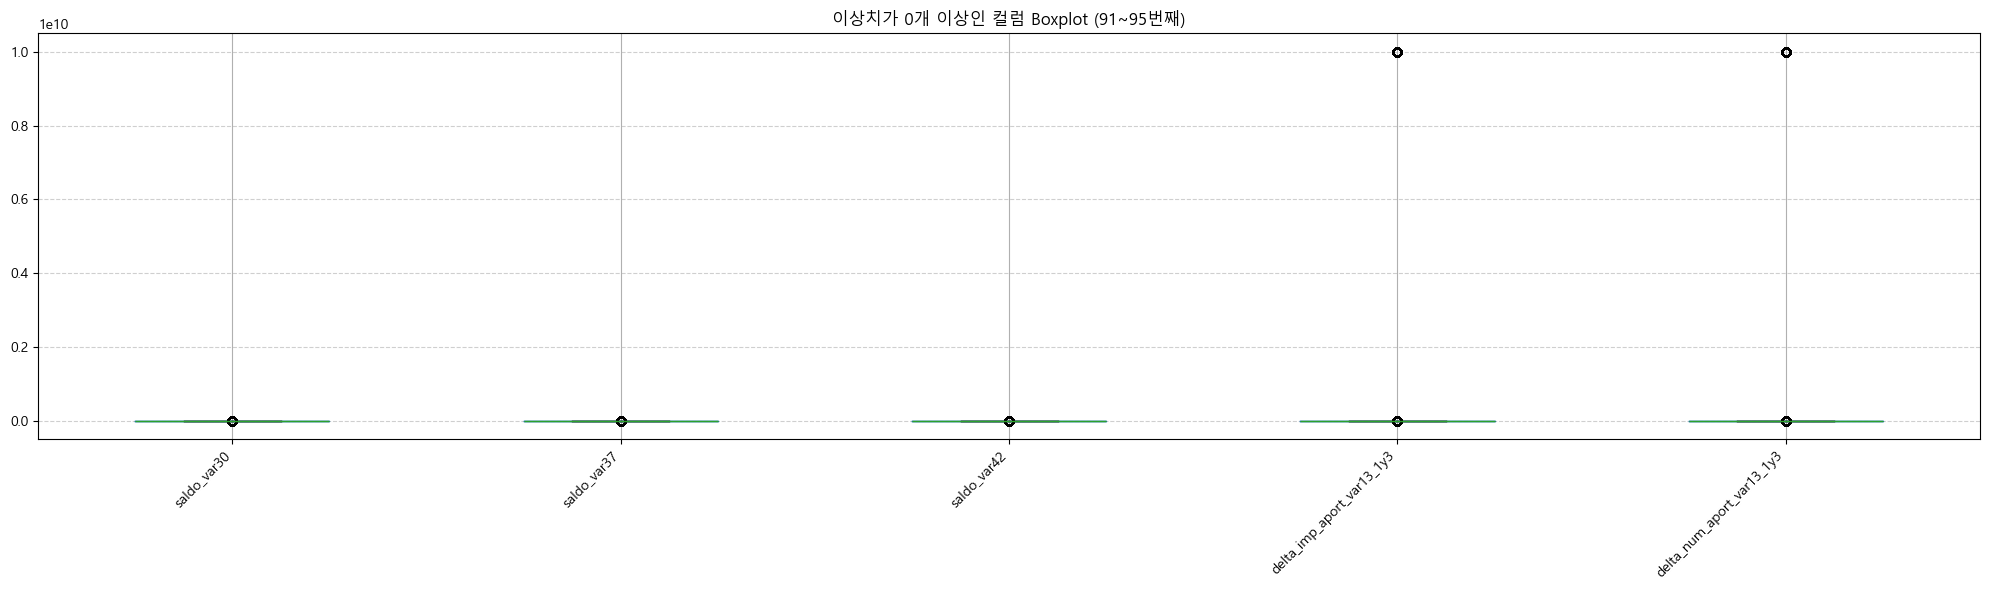

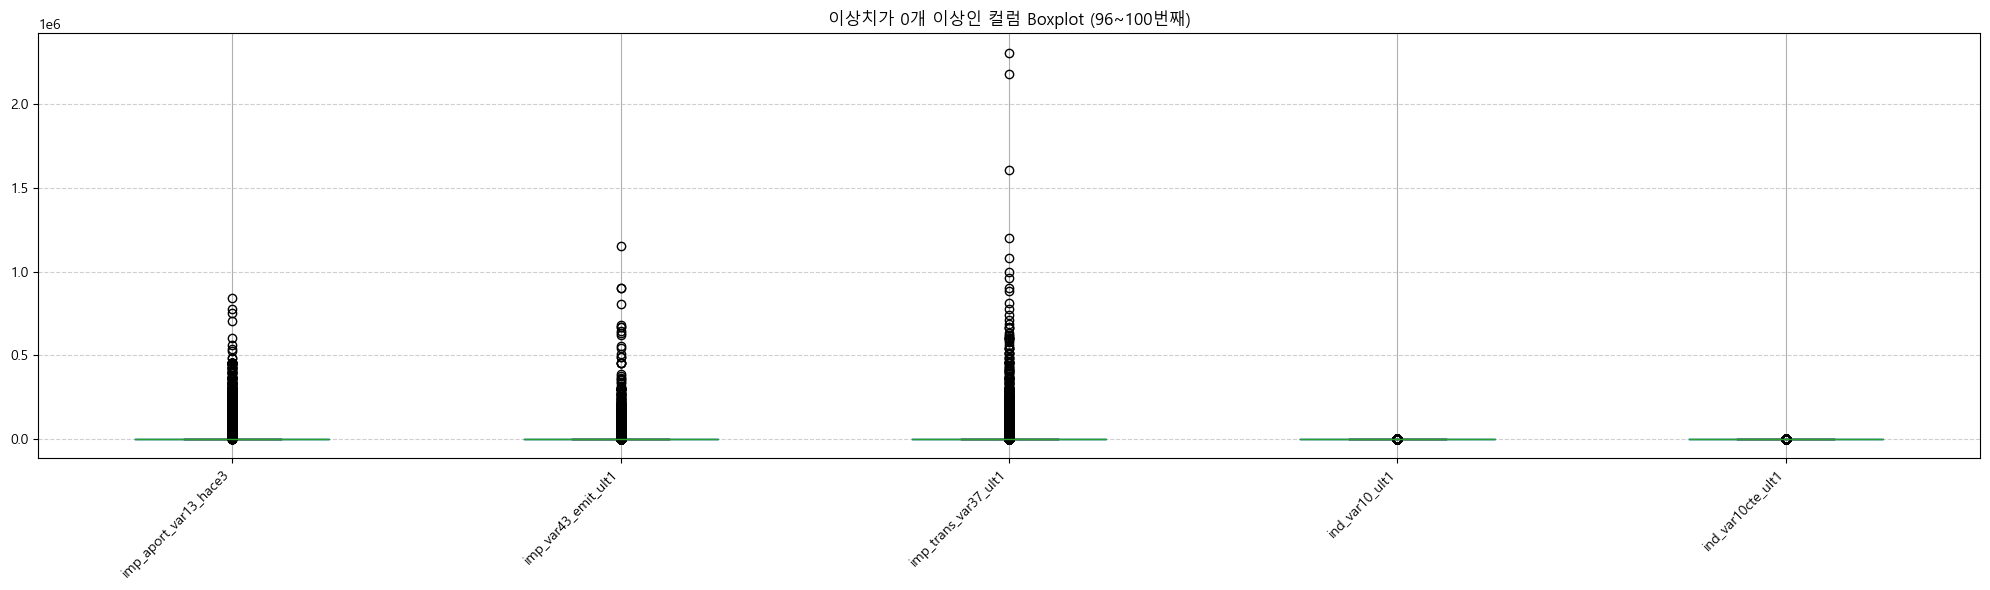

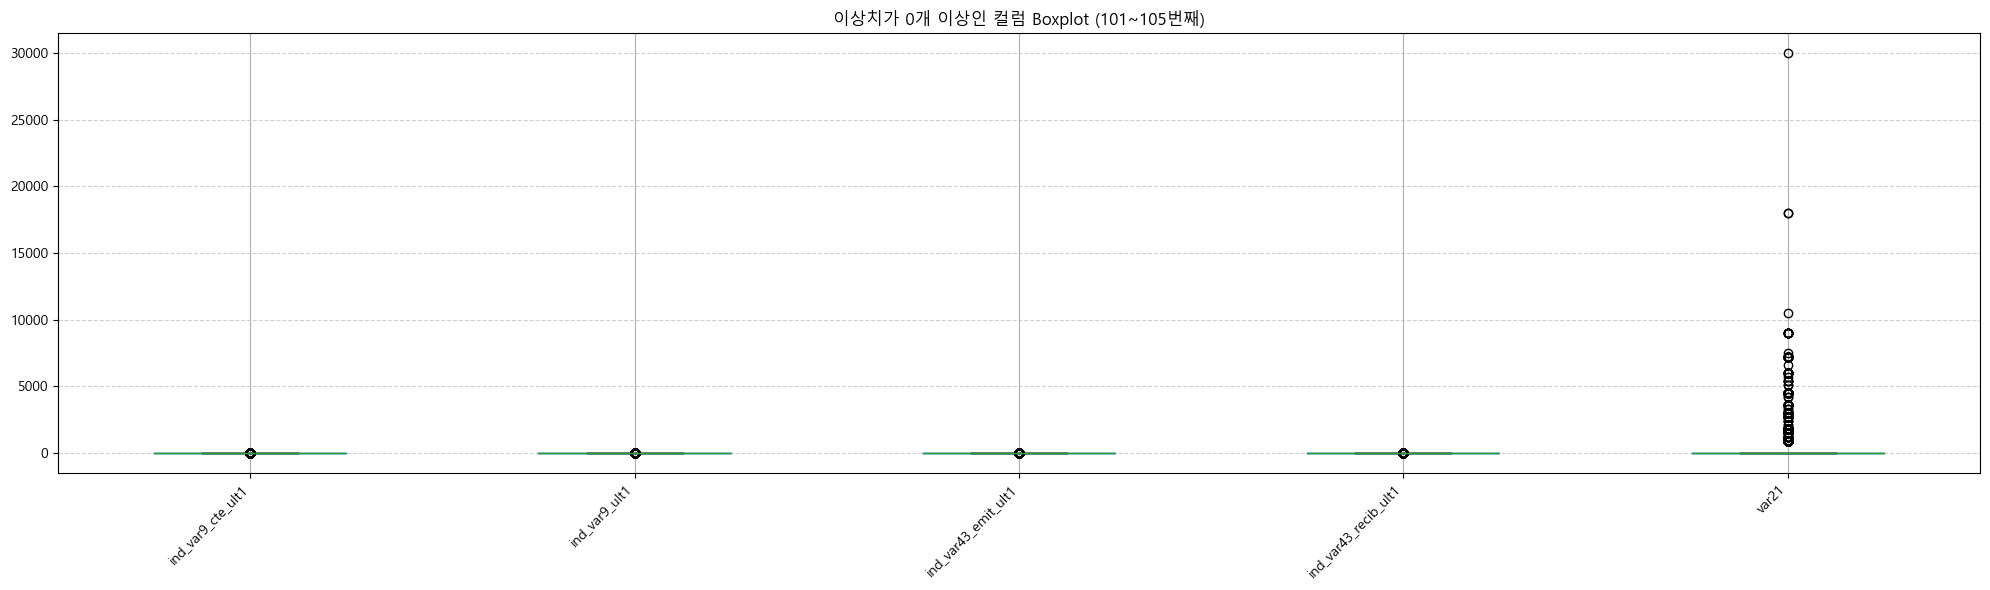

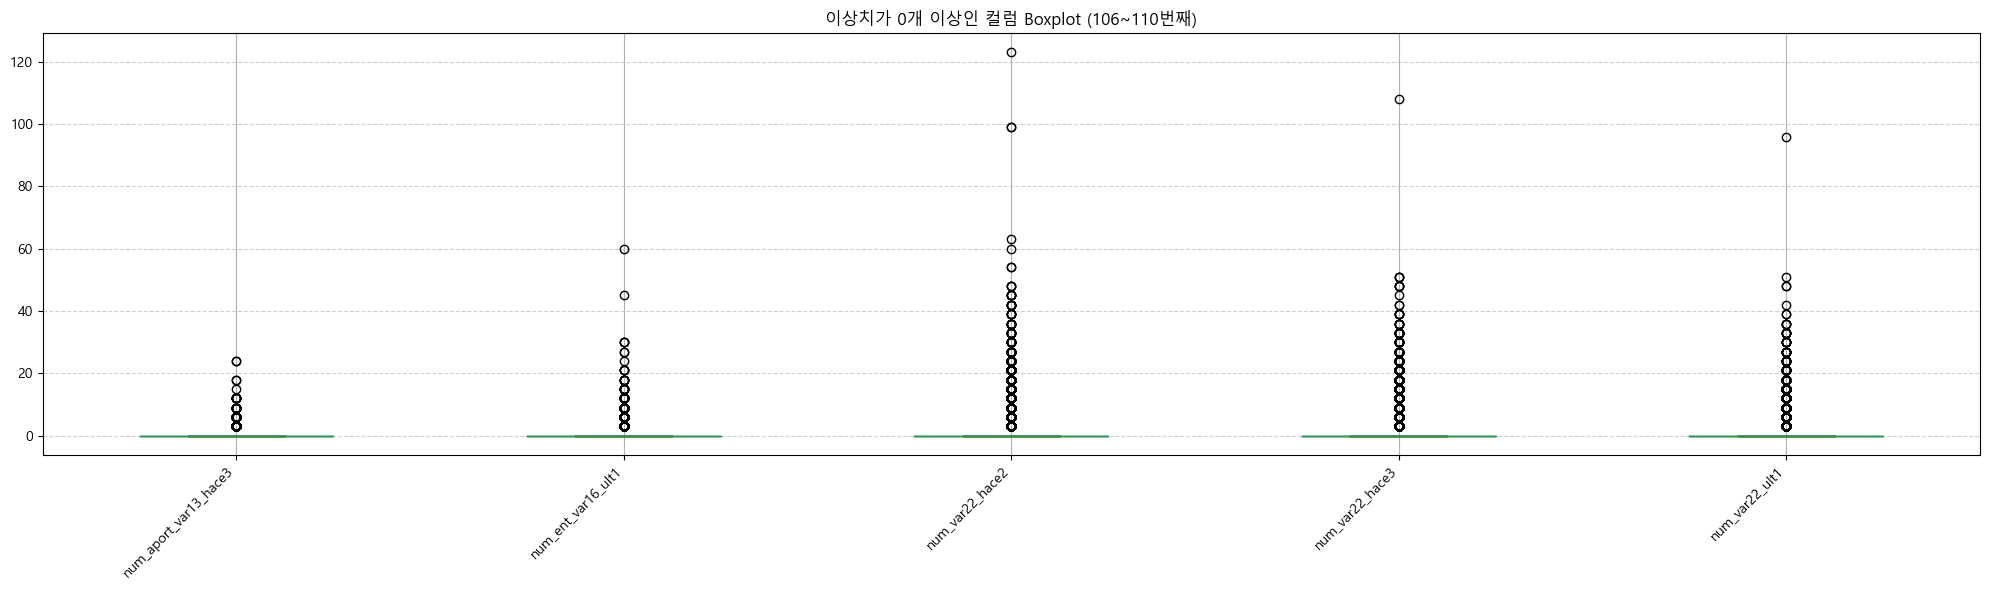

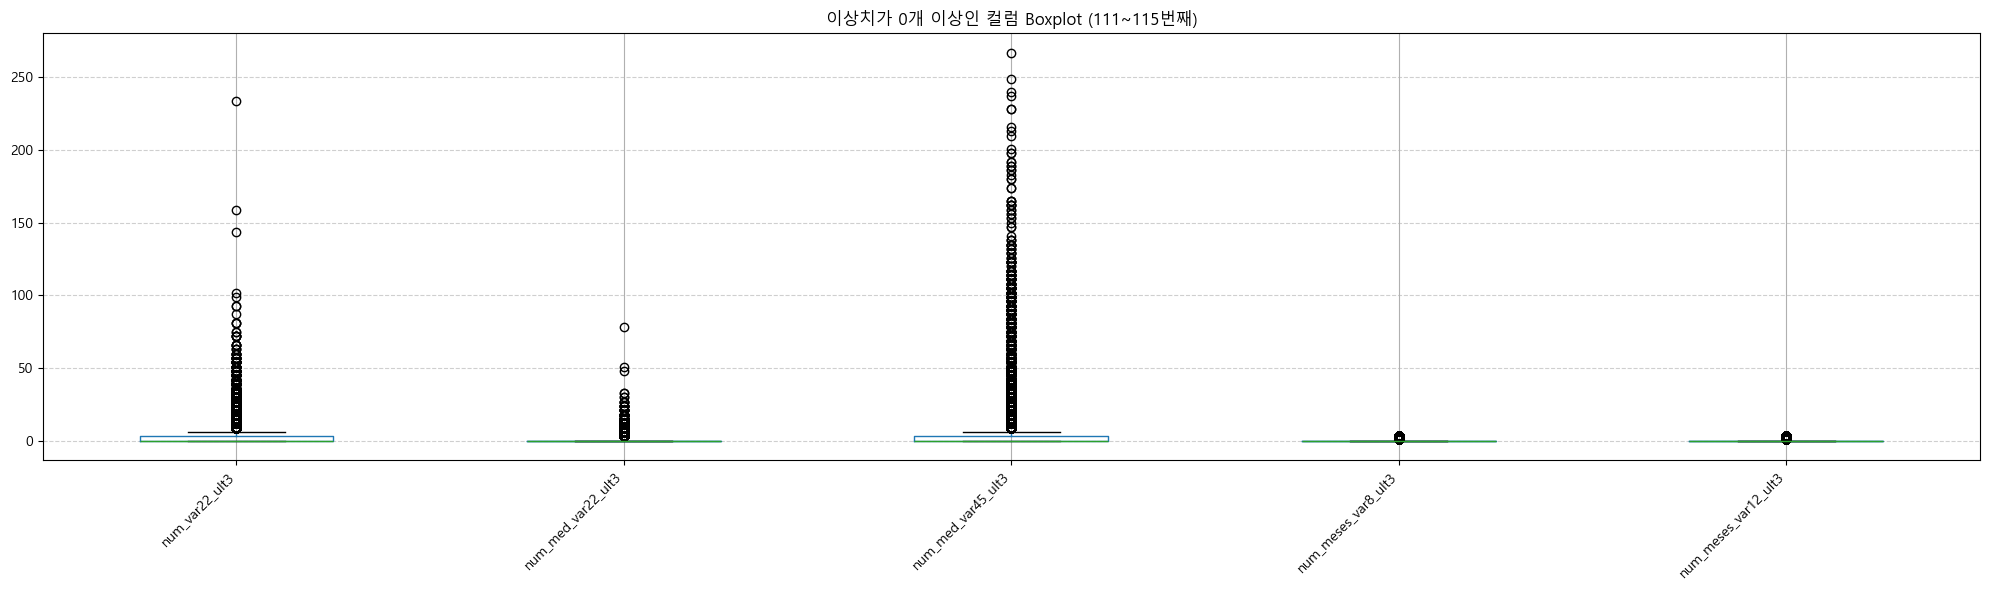

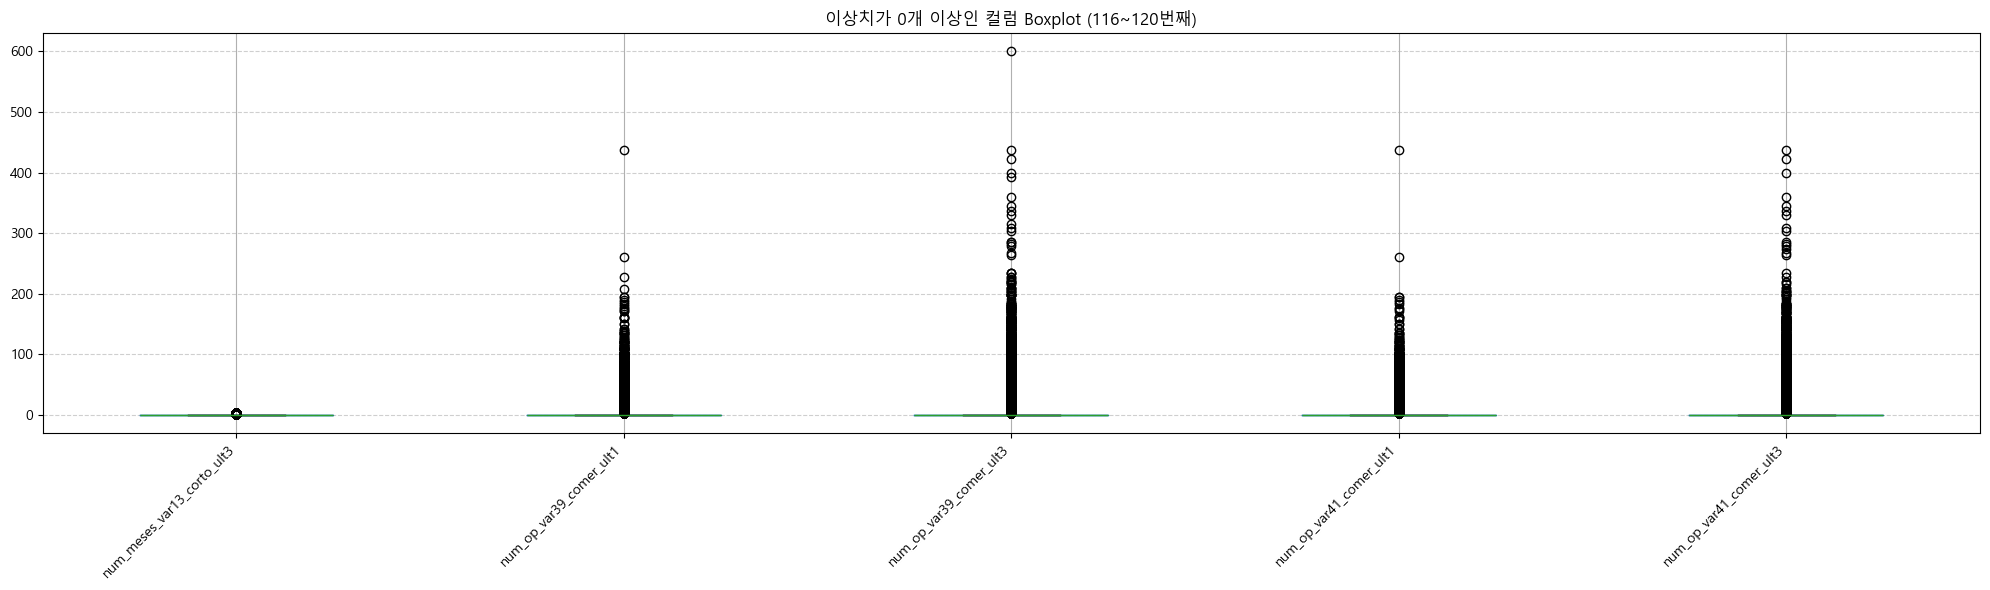

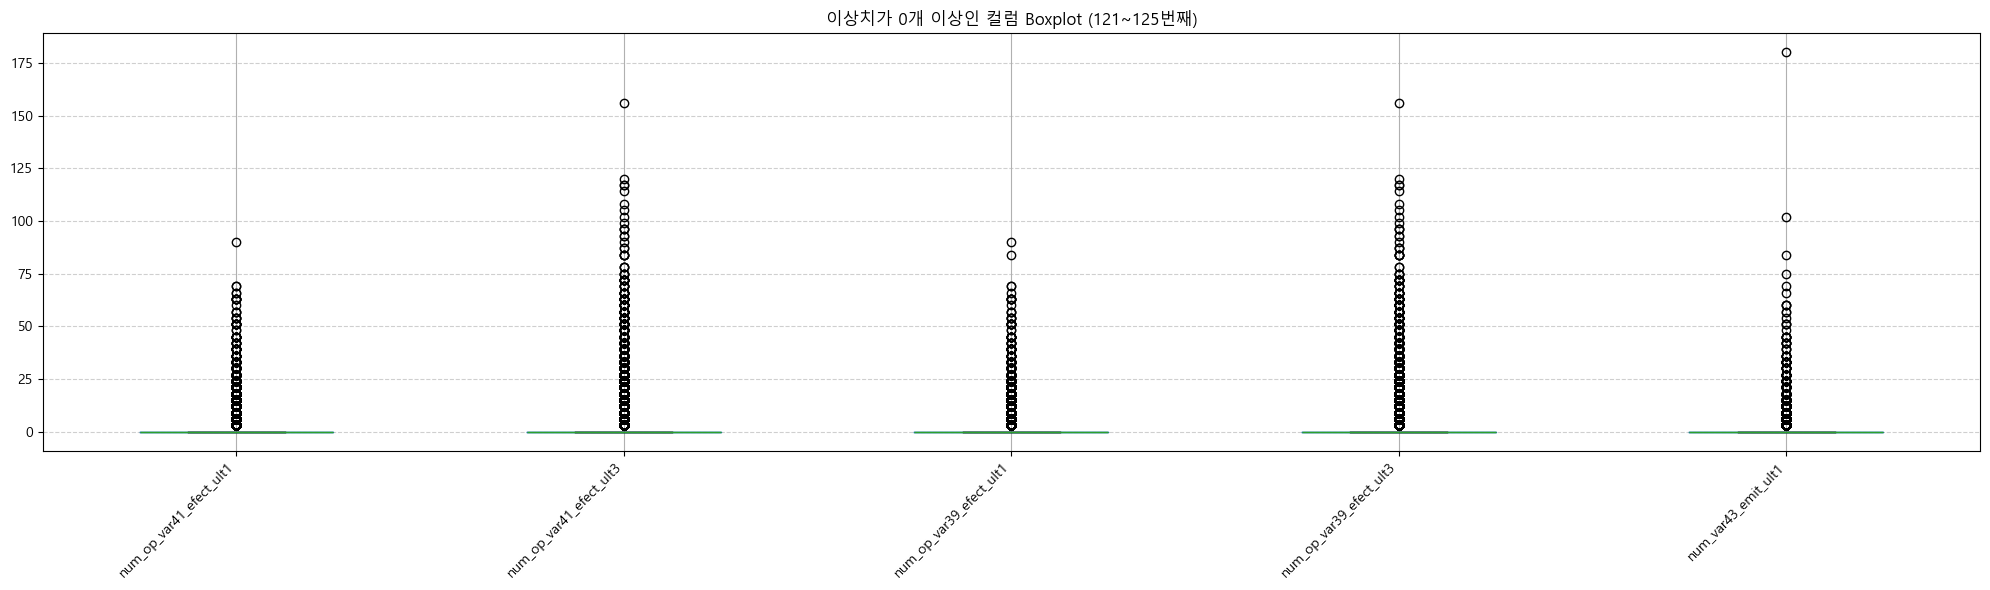

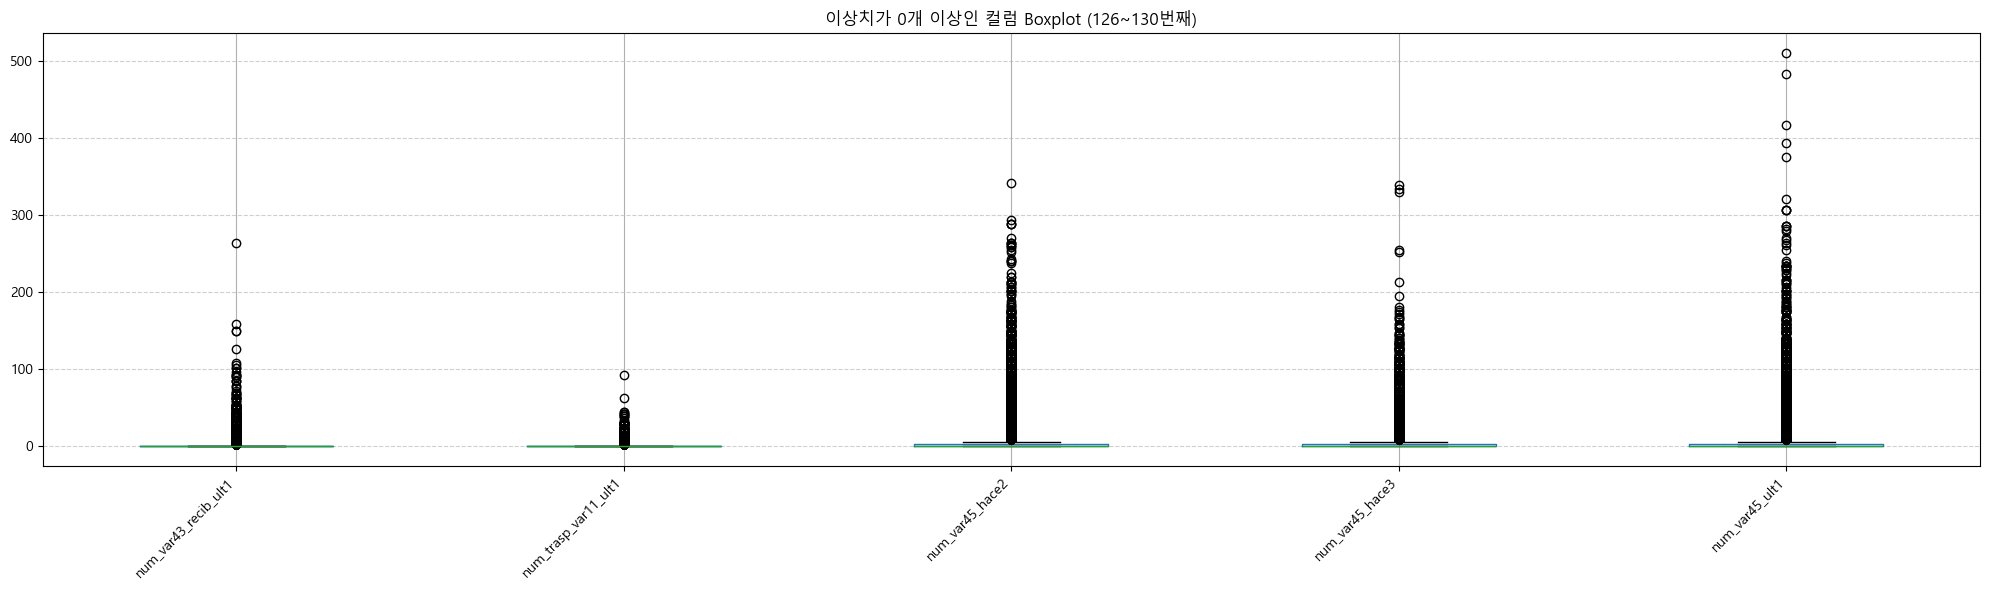

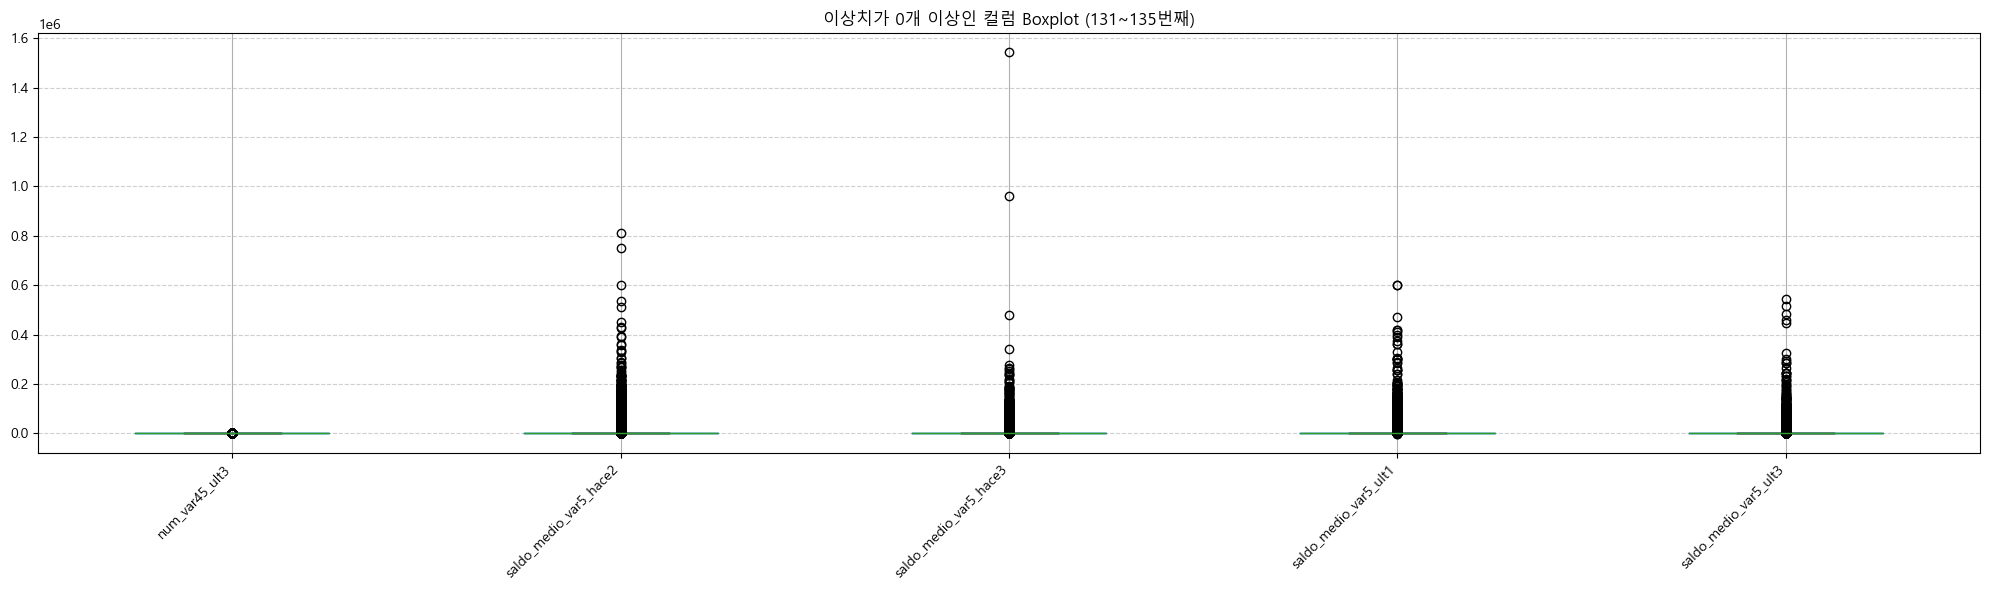

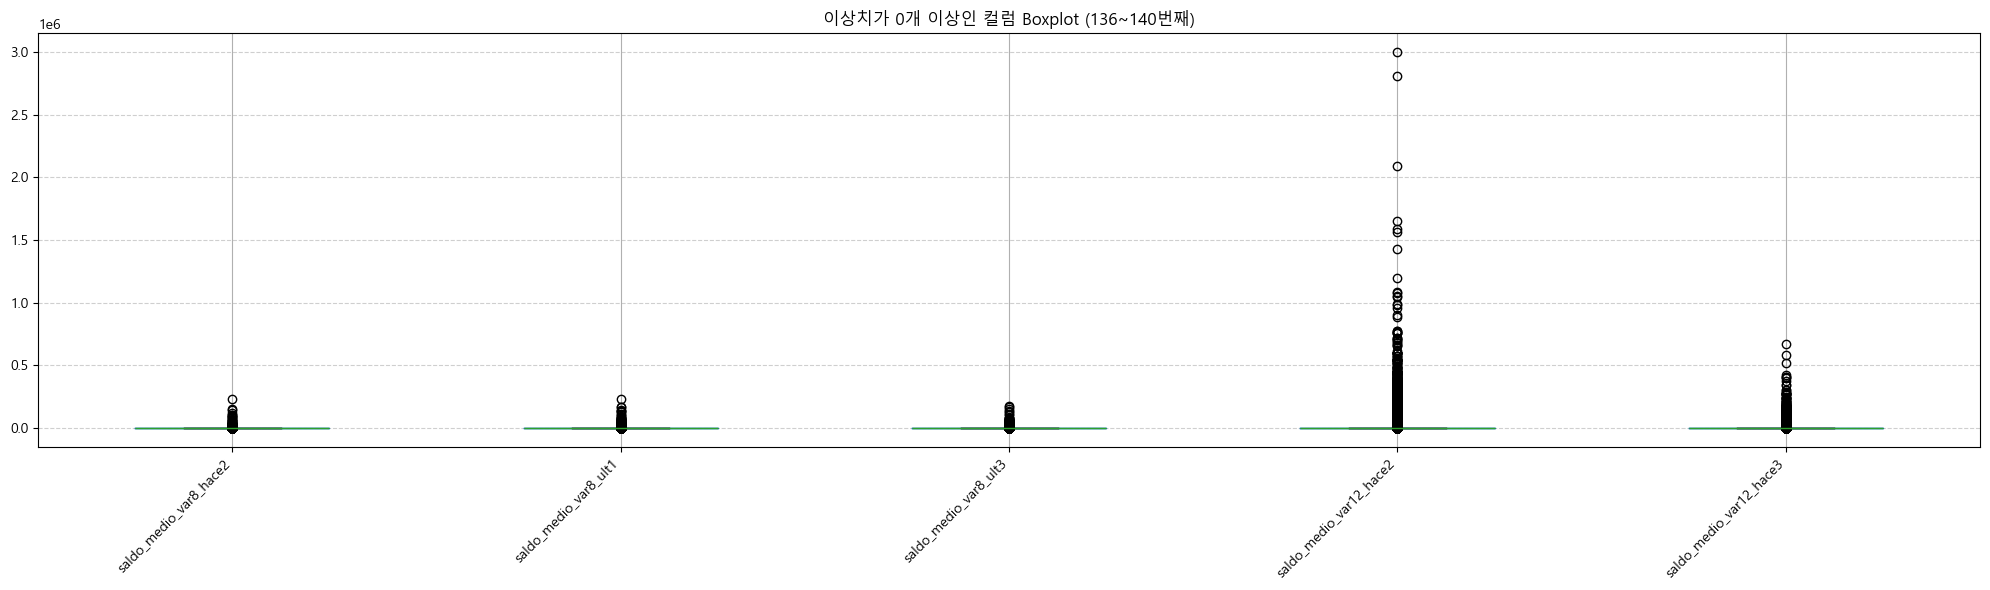

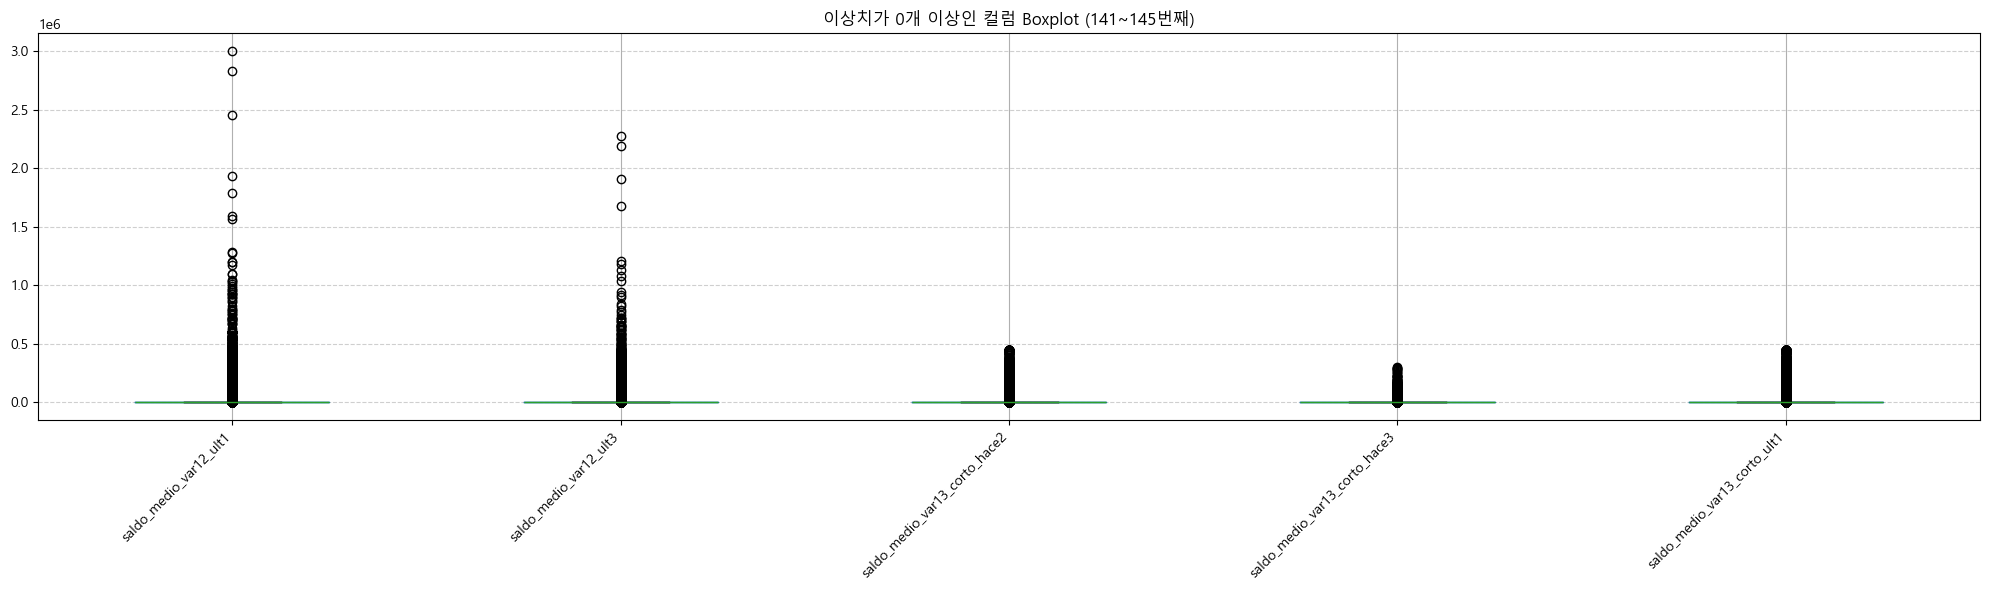

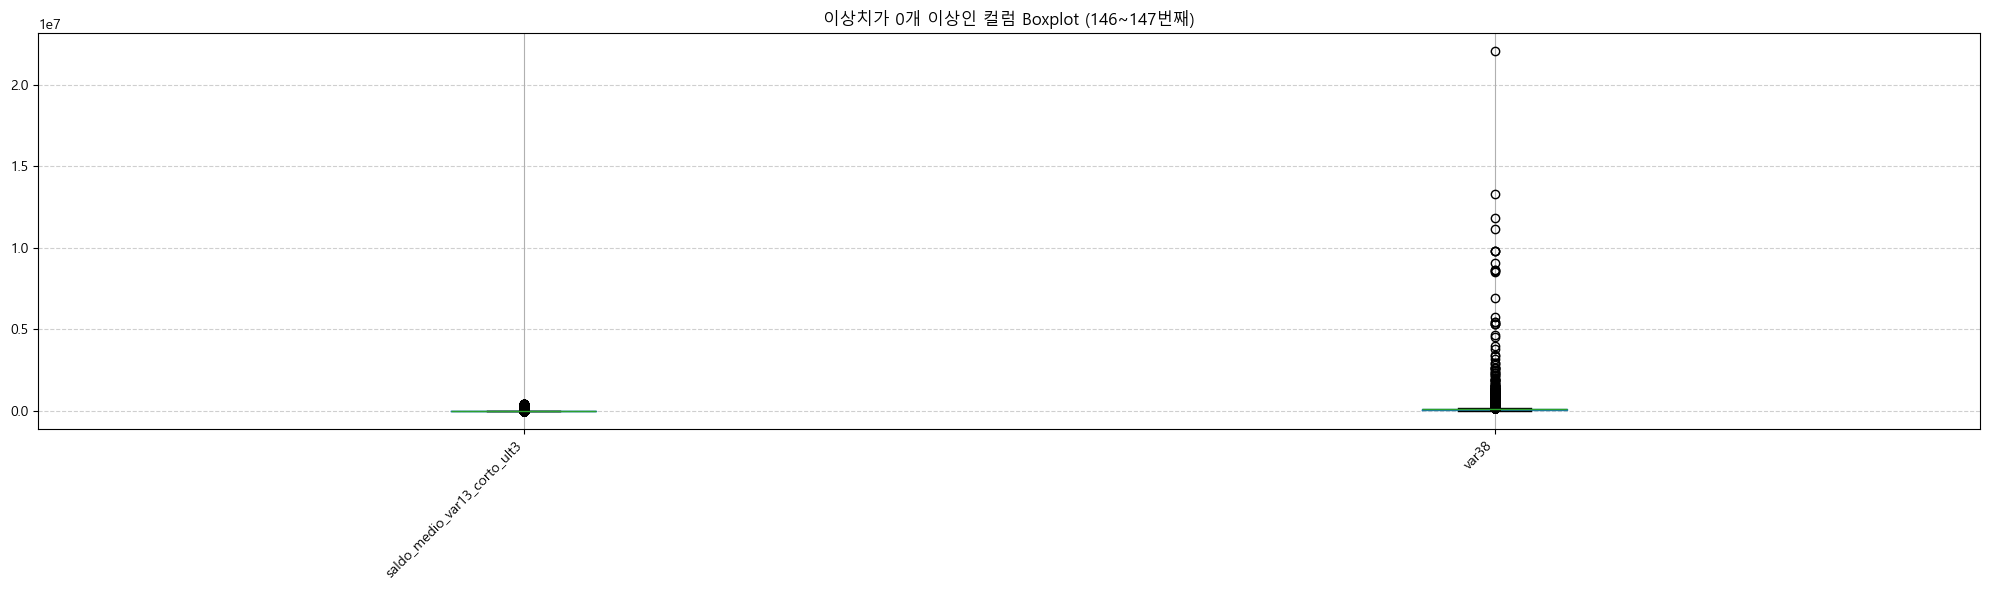

In [33]:
# 6. 10개씩 나눠서 Boxplot 시각화
chunk_size = 5
for i in range(0, len(selected_cols), chunk_size):
    chunk = selected_cols[i:i + chunk_size]
    
    plt.figure(figsize=(20, 6))
    df[chunk].boxplot()
    plt.title(f"이상치가 {ncnt}개 이상인 컬럼 Boxplot ({i+1}~{i+len(chunk)}번째)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
